# ANALYSE EXPLORATOIRE DE DONNÉES  

Ce notebook vise à produire une analyse exploratoire de données, de raconter l'histoire des données de nexacommerce, ce qui constitueras notre rapport final. L'objectif seras donc :

1.  Nettoyer et normalise les données

2.  Des visualisation pour raconter l'histoire de la données

3.  Identifiez les insights les plus actionnables 

**Objectifs** : *Racontez les données de nexacommerce*

## Chargement des données 

Ici nous importons les données, les biblothèques que nous allons utiliser tout au long de notre notebook ainsi que les configurations.

In [ ]:
from nexacommerce.config import *
from nexacommerce.inspection import inspect_dataset
from datetime import datetime
from scipy.stats import ttest_ind
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import re

orders = pd.read_csv(ORDERS_FILE, encoding="utf-8", sep=",", low_memory=False) 
order_items = pd.read_csv(ORDER_ITEMS_FILE, encoding="utf-8", sep=',', low_memory=False)
customers = pd.read_csv(CUSTOMERS_FILE, encoding='utf-8', sep=",", low_memory=False )
couriers = pd.read_csv(COURIERS_FILE, encoding="utf-8", sep=",", low_memory=False)

# style pour les rapports
plt.style.use('seaborn-v0_8-whitegrid') # fond clair, grille discrète

# Paramètres globaux pour la cohérence visuelle
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': False,
    'figure.autolayout': True,
})


# Couleurs 
COLORS = {
    'Douala': '#2A67A6',
    'Yaounde': '#F28C28',
    'Bafoussam': '#1A6B3C',
    'danger': '#8B1A1A',
    'neutral': '#999999',
    'median': '#8B1A1A'
}

sns.set_theme(
    style='whitegrid',
    # fond blanc avec grille légère
    palette='tab10',
    # palette qualitative distincte
    font_scale=1.1,
    # taille globale de police
    rc={
    'figure.figsize':
    (12, 6),
    'figure.dpi':
    150,
    'axes.spines.top': False,
    'axes.spines.right':False,
    }
)

palette_dhi = sns.color_palette(['#2A67A6','#F28C28','#1A6B3C',
'#8B1A1A','#4A235A','#C96A10'])
sns.set_palette(palette_dhi)    


# Palette pour les graphiques multi-catégories
PALETTE = ['#2A67A6','#F28C28','#1A6B3C','#8B1A1A','#4A235A','#C96A10']

## Pipeline de nettoyage 

Ici nous aurons pour but de comprendre les données et enfin de nettoyer ce qui ne vas pas dans la donnée:
 
- normalisation des statuts,

- normalisation des villes,

- normalise les dates,

- correction analytique des montants, 

- déduplication des clients.

In [3]:
# Inspection des valeurs sur orders 
inspection_orders = inspect_dataset(orders)
# Inspection des valeurs sur customers
inspection_customer = inspect_dataset(customers) 

print(inspection_customer)
print(inspection_orders)

# Doublons des id de orders et téléphone dand customer 
print(f'Doublons complets : {orders.duplicated().sum()}')
print(f'order_id unique: {orders["order_id"].nunique()} / {len(orders)}')
print(f'Doublons numéro téléphone: {customers[customers["phone"].notna()].duplicated(subset="phone", keep=False).sum()}')
print(f'Téléphone unique: {customers["phone"].nunique()} / {len(customers)} ')


for col in ['product_category']:
    print(f'\n{col} ({order_items[col].nunique()} valeurs unique dans order_items)')
    print(order_items[col].value_counts(dropna=False).head(10))
    
# Nombre doublons de téléphone dans la table Order
doublons = customers[customers['phone'].notna()].duplicated(subset='phone', keep=False)
print(f'\nClients avec doublons téléphone : {doublons.sum()}')       


{'rows': 2380, 'cols': 7, 'dtypes': {'customer_id': 'str', 'name': 'str', 'phone': 'str', 'registration_date': 'str', 'city': 'str', 'quartier': 'str', 'loyalty_score': 'float64'}, 'missing_counts': {'customer_id': 0, 'name': 0, 'phone': 0, 'registration_date': 0, 'city': 0, 'quartier': 0, 'loyalty_score': 151}, 'missing_percentages': {'customer_id': 0.0, 'name': 0.0, 'phone': 0.0, 'registration_date': 0.0, 'city': 0.0, 'quartier': 0.0, 'loyalty_score': 6.34}, 'columns_with_missing': ['loyalty_score'], 'duplicate_count': 0, 'duplicate_percentage': 0.0, 'unique': {'customer_id': 2380, 'name': 2204, 'phone': 2308, 'registration_date': 1074, 'city': 14, 'quartier': 64, 'loyalty_score': 819}, 'not_null': {'customer_id': 2380, 'name': 2380, 'phone': 2380, 'registration_date': 2380, 'city': 2380, 'quartier': 2380, 'loyalty_score': 2229}}
{'rows': 12500, 'cols': 12, 'dtypes': {'order_id': 'int64', 'customer_id': 'str', 'order_date': 'str', 'delivery_time_min': 'float64', 'status': 'str', 'tot

## Normalisation ds données 

La cellule précedente nous montre des variations de ligne et de colonne sur la table ordes et customers :

- 17 variantes de statut plus ou moins identique avec aucune ligne vides,

- 14 Valeur de ville plus ou moins identifque et aucune ligne vides,

- Normalisation des dates,

- 38 valeur de product category qui sont identiques mais avons des noms plus ou moins identiques et des valeurs dont je vais remplacer en joinant order_items,  

- Des valeurs null à loyalty_score pour la table customer que je vais remettre à 0 plus cohérent et supérieur à 100 je ramene à 100,     

- Des montants négatifs que je vais mettre en valeur absolute, 

- Des valeurs nulle à delivery_time_min de la table orders que je vais inputer par la médianne.

- Les montants sont en float ramener dans un type int.

### Normalisation des données

#### Normalisation des status

In [4]:
def status_normalise(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if value in {"LIVRE", "livre", "livré"}:
        return "delivered"
    if value in {"en_retard", "en retard", "retard", "En_retard", "EN_RETARD"}:
        return "late"
    if value in {"annule", "ANNULE",'annulé'}:
        return "cancelled"
    if value in {"en_cours", "en cours","En_cours"}:
        return "in_progress"
    return value.strip().lower().capitalize()

#### Normalisation des villes

In [5]:
def city_normalise(value):
    if pd.isna(value):
        return np.nan
    if value in {"Yaoundã©","Yaoundã©","YaoundÃ©","Yaoundã©","Yaoundé",'yaounde'}:
        return "Yaounde"
    value = str(value).strip().lower()
    return value.capitalize()    

#### Normalisation des dates


In [6]:
orders['order_date'] = pd.to_datetime(orders['order_date'], dayfirst=True, format='mixed', errors='coerce')

#### Normalisation des numeros de teléphone de la table customers

In [7]:
def normalise_phone(phone):
    if pd.isna(phone): 
        return None    
    digits = re.sub(r'\D', '', str(phone))    
    if digits.startswith('237') and len(digits) == 12:
        digits = digits[3:]        
    if len(digits) == 9 and digits[0] in ('6', '2'):
        return digits
    return None 

#### Imputation à la médiane de delivery_time_min

Ici nous ramenons les valeurs qui sont nul à la mediane

In [8]:
médiane_durée = orders['delivery_time_min'].median()
print(f'Médiane durée : {médiane_durée:.1f} min')

# Les delivery time à null nous les ramenons à la médianne
orders['delivery_time_min'] = orders['delivery_time_min'].fillna(médiane_durée)

Médiane durée : 45.7 min


#### Violation 2NF supression de la table catégories dans orders

In [9]:
#Supprimer la table product_category 
orders = orders.drop(columns=['product_category'])

#### Correction des totals amount

In [10]:
# calculer la somme par order_id dans order_items
items_sum = order_items.dropna(subset=["order_id", "line_total_xaf"]).copy()

# Mettre en numerique
# items_sum["line_total_xaf"] = pd.to_numeric(items_sum["line_total_xaf"], errors="coerce")

# déplacer/renommer la colonne dans orders["total_amount_xaf"]
items = order_items[['order_id', 'line_total_xaf']].dropna().copy()

# Grouper les orders_id de orders_items
sum_per_order = items.groupby('order_id', as_index=True)["line_total_xaf"].sum().rename('total_amount_xaf_clean')

orders = orders.merge(sum_per_order, left_on="order_id", right_index=True, how="left")

# Mettre dans la colonne total

orders['ecart_montant'] = orders['total_amount_xaf'] - orders['total_amount_xaf_clean']

# Affichage des commandes sans clients
clients_valides = customers['customer_id'].unique()

# On filtre les commandes : ON GARDE celles où le customer_id N'EST PAS (le ~) dans la liste des valides
commandes_orphelines = orders[~orders['customer_id'].isin(clients_valides)].copy()

# Affichage du résultat
print(f" Nombre de commandes sans clients identifiés : {len(commandes_orphelines)}")
display(commandes_orphelines)


clients_actifs = orders['customer_id'].dropna().unique()

# Client sans commandes
clients_sans_commandes = customers[~customers['customer_id'].isin(clients_actifs)].copy()

# 3. Affichage du résultat
print(f"Nombre de clients inscrits mais sans AUCUNE commande : {len(clients_sans_commandes)}")
display(clients_sans_commandes)

display(orders)


 Nombre de commandes sans clients identifiés : 367


,order_id,customer_id,order_date,delivery_time_min,status,total_amount_xaf,city,quartier,courier_id,order_hour,order_day_of_week,total_amount_xaf_clean,ecart_montant
65,100065,CUST90687,2023-11-26 12:18:00,40.7,livré,-477.0,Yaoundé,Briqueterie,45,12,Sunday,18821.0,-19298.0
82,100082,CUST90163,2023-11-27 16:23:00,38.2,livré,18214.0,douala,Ndogpassi,20,16,Monday,5953.0,12261.0
96,100096,CUST90175,2024-04-23 21:21:00,22.7,livré,7643.0,BAFOUSSAM,Centre Ville,2,21,Tuesday,8816.0,-1173.0
99,100099,CUST90916,2025-02-06 17:23:00,78.4,livré,118709.0,douala,Yassa,29,17,Thursday,27271.0,91438.0
178,100178,CUST90829,2022-05-03 00:00:00,74.9,Livré,5940.0,Douala,Cité des Palmiers,37,17,Tuesday,12050.0,-6110.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12300,112300,CUST90807,2022-09-10 19:55:00,67.2,livré,43723.0,douala,Ngodi-Bakoko,11,19,Saturday,1803.0,41920.0
12383,112383,CUST90040,2024-10-07 19:17:00,54.5,livré,12799.0,Douala,Bonabéri,43,19,Wednesday,6371.0,6428.0
12386,112386,CUST90050,2025-01-05 00:00:00,27.2,livré,6325.0,Douala,Mboppi,3,12,Sunday,27892.0,-21567.0
12402,112402,CUST90357,2024-05-20 00:00:00,23.8,livré,15000.0,Bafoussam,Mossap,30,20,Monday,8193.0,6807.0


Nombre de clients inscrits mais sans AUCUNE commande : 17


,customer_id,name,phone,registration_date,city,quartier,loyalty_score
185,CUST11222,Laurent issa,+237648412328,2022-04-07,douala,PK8,NaN
418,CUST10732,KENFACK Romain,689470029,2024-04-11,Douala,New-Bell,40.0
510,CUST17150,Mireille MAROUF,641329612,2023-04-20,DOUALA,Beedi,7.3
513,CUST10651,Jules ATEBA,675529051,2022-07-31,Yaounde,Nkomo,53.1
664,CUST11479,Christiane OBAMA,+237690585678,2024-06-01,Yaoundé,Efoulan,44.2
798,CUST10916,Solange mengue,+237631079846,2021-07-27,BAFOUSSAM,Djeleng,32.1
1202,CUST11899,Rabi wamba,679172559,2022-09-29,douala,Bonapriso,47.3
1218,CUST11060,Sandrine FEUDJIO,+237665766169,2023-01-16,bafoussam,Bamougoum,65.6
1251,CUST11261,Romain ESSAMA,+237625457816,2021-03-17,BAFOUSSAM,Tamdja,36.6
1287,CUST11627,Isabelle nkolo,00237 6 54703713 85 48 66,2023-05-22,Douala,Ndog-Bong,11.9


,order_id,customer_id,order_date,delivery_time_min,status,total_amount_xaf,city,quartier,courier_id,order_hour,order_day_of_week,total_amount_xaf_clean,ecart_montant
0,100000,CUST11954,2024-07-06 14:31:00,44.7,livré,15444.0,YAOUNDE,Biyem-Assi,47,14,Friday,7594.0,7850.0
1,100001,CUST11317,2024-04-20 18:56:00,53.9,livré,16188.0,Yaounde,Messa,32,18,Saturday,227.0,15961.0
2,100002,CUST17374,2024-10-07 17:37:00,260.7,en_retard,11497.0,Douala,Bonabéri,32,17,Wednesday,10159.0,1338.0
3,100003,CUST10224,2023-03-29 07:48:00,253.8,en_retard,20301.0,Yaounde,Nlongkak,22,7,Wednesday,17776.0,2525.0
4,100004,CUST11846,2024-12-29 08:35:00,66.5,livré,15639.0,yaounde,Bastos,30,8,Sunday,1318.0,14321.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12495,112495,CUST11295,2024-05-22 19:42:00,202.8,EN_RETARD,39113.0,bafoussam,Mossap,28,19,Wednesday,5292.0,33821.0
12496,112496,CUST11910,2023-07-02 18:26:00,41.4,livré,4776.0,BAFOUSSAM,Lekie,21,18,Tuesday,2298.0,2478.0
12497,112497,CUST11847,2023-05-06 00:00:00,50.3,livré,50750.0,DOUALA,Bonabéri,35,9,Saturday,26402.0,24348.0
12498,112498,CUST10517,2023-10-05 13:19:00,10.1,annulé,18000.0,Douala,Makepe,33,13,Thursday,1820.0,16180.0


#### Loyalty_score ramener à 100 et mettre à 0 

In [11]:
abérantes = (customers['loyalty_score'] > 100).sum()
print(f'\nNombre de valeurs supérieur à 100 : {abérantes}')

customers['loyalty_score'] = customers['loyalty_score'].clip(lower=0, upper=100)

#Médianne loyalty_score
customer_mean = customers['loyalty_score'].mean() 

# Mettre les loyalty score 0 à la médianne
customers['loyalty_score'] = customers['loyalty_score'].fillna(customer_mean)


Nombre de valeurs supérieur à 100 : 107


#### Déduplication des clients



In [ ]:
print(f"Téléphones valides trouvés : {customers['phone'].notna().sum()}")

Téléphones valides trouvés : 1918
Téléphones invalides/isolés : 0


### Application des normalisation sur les différentes tables

In [13]:
orders['status']  = orders['status'].map(status_normalise)
customers['city'] = customers['city'].map(city_normalise)
orders['city'] = orders['city'].map(city_normalise)
customers['phone'] = customers['phone'].map(normalise_phone) 

# Suppression de doubons de customers
customers['phone'] = customers['phone'].fillna('INVALID')

customers_dedup = (
    customers
    .sort_values(by="registration_date", ascending=True)
    .drop_duplicates(subset=["phone"], keep="first")
    .copy()
)



Téléphones invalides/isolés : 0


#### Application du customers

In [16]:
customers = (
    customers
    .sort_values(by="registration_date", ascending=True) 
    .drop_duplicates(subset=["phone"], keep="first") 
    .copy()
    .reset_index(drop=True)
)


Téléphones invalides/isolés : 0


### Verification des données correcte

In [18]:
print(inspection_orders)
print(inspection_customer)


# == Verification du customers ===
print(f"Téléphones valides trouvés : {customers['phone'].notna().sum()}")
print(f"Téléphones invalides/isolés : {customers['phone'].isna().sum()}")

# Verification
print("\n" + "="*20)
print("RAPPORT DE DÉDUPLICATION CLIENTS")
print("="*20)
print(f"Clients bruts initiaux     : {customers.shape[0]:,}")
print(f"Clients dédupliqués (fin)  : {customers_dedup.shape[0]:,}")
print(f"Doublons supprimés         : {customers.shape[0] - customers_dedup.shape[0]:,}")
print(f"Réduction de la base      : {((customers.shape[0] - customers_dedup.shape[0]) / customers.shape[0]) * 100:.1f}%")


{'rows': 12500, 'cols': 12, 'dtypes': {'order_id': 'int64', 'customer_id': 'str', 'order_date': 'str', 'delivery_time_min': 'float64', 'status': 'str', 'total_amount_xaf': 'float64', 'city': 'str', 'quartier': 'str', 'product_category': 'str', 'courier_id': 'int64', 'order_hour': 'int64', 'order_day_of_week': 'str'}, 'missing_counts': {'order_id': 0, 'customer_id': 0, 'order_date': 0, 'delivery_time_min': 1893, 'status': 0, 'total_amount_xaf': 359, 'city': 0, 'quartier': 0, 'product_category': 2078, 'courier_id': 0, 'order_hour': 0, 'order_day_of_week': 0}, 'missing_percentages': {'order_id': 0.0, 'customer_id': 0.0, 'order_date': 0.0, 'delivery_time_min': 15.14, 'status': 0.0, 'total_amount_xaf': 2.87, 'city': 0.0, 'quartier': 0.0, 'product_category': 16.62, 'courier_id': 0.0, 'order_hour': 0.0, 'order_day_of_week': 0.0}, 'columns_with_missing': ['delivery_time_min', 'total_amount_xaf', 'product_category'], 'duplicate_count': 0, 'duplicate_percentage': 0.0, 'unique': {'order_id': 1250

## Visualisation 

Ici nous devrons mettre à disposition des visualisation qui porteront sur : 

- l'evolution temporelle du volume de commandes

- La répartition géographique des performances 

- Le profil de clients actifs contre ceux inactifs

- L'analyse de crénaux horaires

### Montrons l'évolution du chiffre d'affaire par mois

In [ ]:

status_invalides = ['cancelled', 'in_progress' ]
df_filtered = orders[~orders['status'].str.lower().isin(status_invalides)].copy()

df_filtered['order_date'] = pd.to_datetime(df_filtered['order_date'])

monthly_finance = (df_filtered.groupby(df_filtered['order_date'].dt.to_period('M'))
                   .agg({
                       'total_amount_xaf_clean': 'sum', 
                       'order_id': 'count'
                        })
                   .reset_index())

monthly_finance['order_date'] = monthly_finance['order_date'].dt.to_timestamp()
monthly_finance.columns = ['Mois', 'Chiffre_Affaires', 'Nombre_Commandes']

fig = px.area(
    monthly_finance, 
    x='Mois', 
    y='Chiffre_Affaires',
    title="Évolution Mensuelle du Chiffre d'Affaires (Commandes Validées)",
    markers=True,
    text=None, 
    labels={'Chiffre_Affaires': 'CA (FCFA)', 'Mois': 'Période'},
    template="plotly_white"
)

fig.update_traces(
    line_color="#E4CA36", 
    line_width=2,
    marker=dict(size=5, color='#E9370B', symbol='circle'),
    hovertemplate="<b>Mois:</b> %{x|%B %Y}<br><b>CA:</b> %{y:,.0f} FCFA<extra></extra>"
)

fig.update_layout(
    xaxis_title="Mois",
    yaxis_title="Chiffre d'Affaires (XAF)",
    hovermode="x unified" 
)

fig.show()

fig.write_html("../reports/EDA/Chiffre_D'affaire.html")
fig.write_image("../reports/EDA/Chiffre_D'affaire.png", scale=2)

#### Commentaire

Cette visualisation permet de voir la dynamique de l'activité dans le temps. Elle aide à repérer les phases d'accélération, les creux d'activité et l'éventuelle saisonnalité du volume de commande. Nous constatons que nous avons eu une reduction enorme du nombre de commande au niveau du mois de février en 2025, les commandes on drastiquement diminuer. 

### Évolution Temporelle du volume de commande

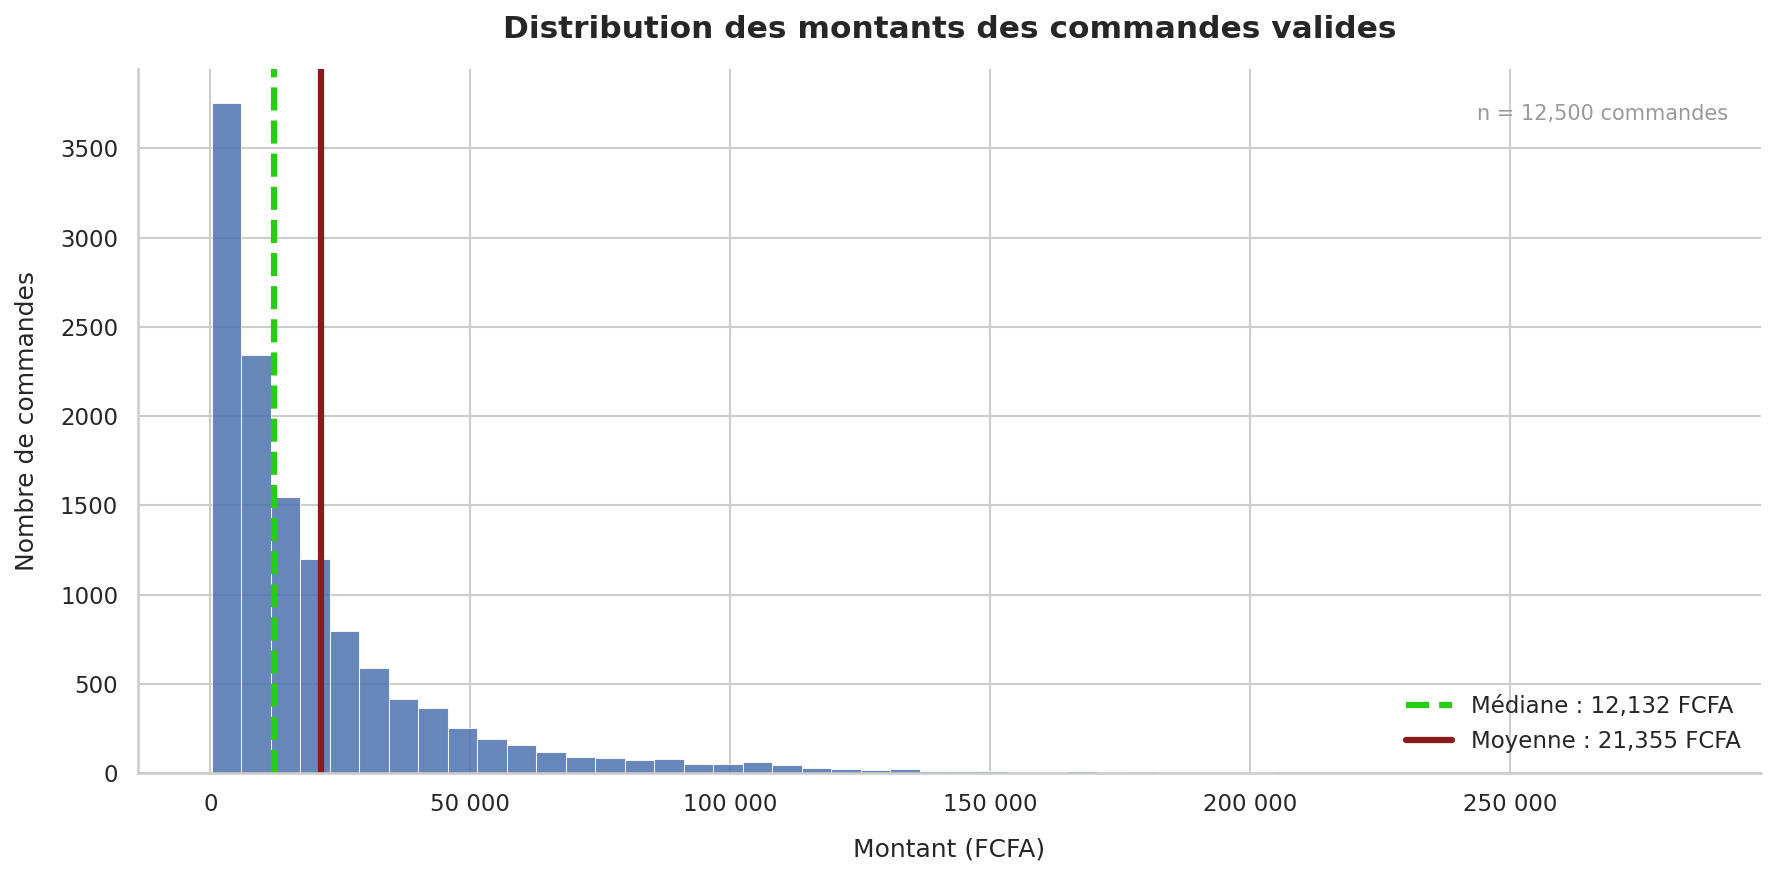

In [ ]:
montants = orders[orders['total_amount_xaf_clean'] > 0]['total_amount_xaf_clean'].dropna()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

ax.hist(montants, bins=50, color=COLORS.get("Yaoundé"), edgecolor='white', linewidth=0.5, alpha=0.85)

ax.set_title("Distribution des montants des commandes valides", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Montant (FCFA)', labelpad=10)
ax.set_ylabel('Nombre de commandes', fontsize=12, labelpad=10)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', ' ')))

ax.axvline(np.median(montants), color="#29CC14", linewidth=3, linestyle='--', 
           label=f'Médiane : {np.median(montants):,.0f} FCFA')
           

ax.axvline(np.mean(montants), color='#8B1A1A', linewidth=3, linestyle='-', 
           label=f'Moyenne : {np.mean(montants):,.0f} FCFA')

ax.legend(fontsize=11)

ax.annotate(f'n = {len(montants):,} commandes', xy=(0.98, 0.95), xycoords='axes fraction', 
            ha='right', va='top', fontsize=10, color='#999999')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

fig.savefig("../reports/EDA/distribution_montants.png", bbox_inches="tight", dpi=150)
plt.show()

### Audit visuel

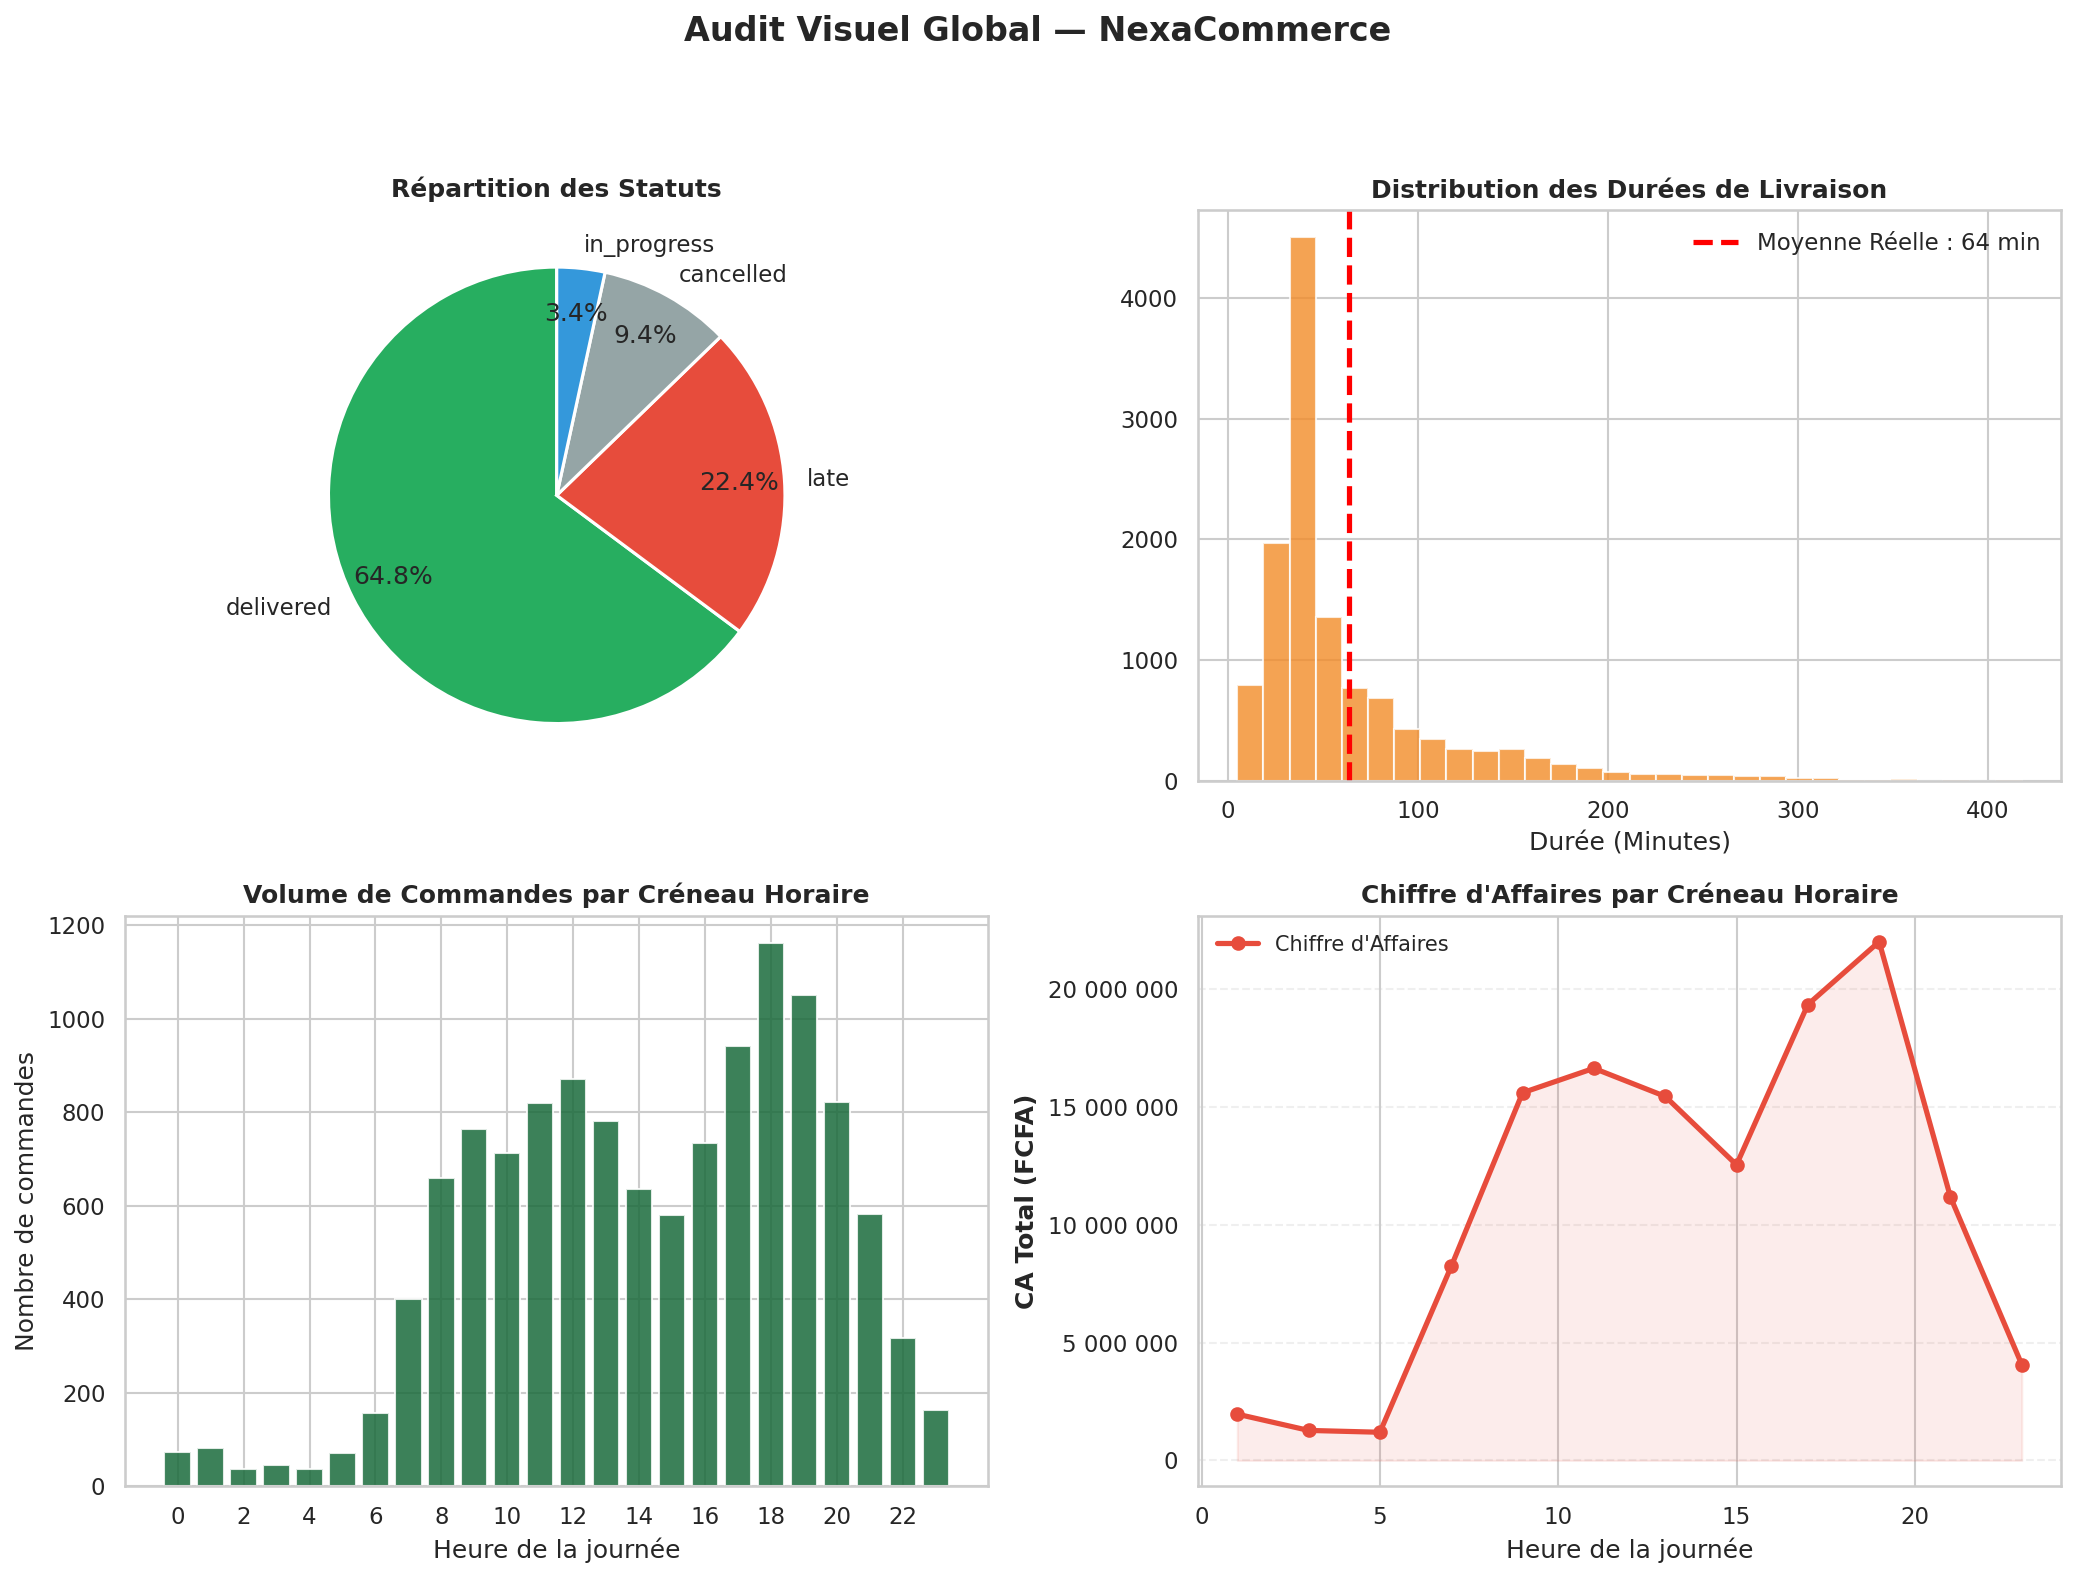

In [116]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

status = orders['status'].value_counts()

durées = orders['delivery_time_min']

heures = orders['order_hour']

ca_heure = orders[(orders['total_amount_xaf_clean'] > 0) & (orders['order_hour'])].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
fig.suptitle("Audit Visuel Global — NexaCommerce", fontsize=16, fontweight='bold', y=1.05)
ax1, ax2, ax3, ax4 = axes.flatten()


status_colors_map = {
    'delivered': '#27AE60', 
    'late': '#E74C3C', 
    'cancelled': '#95A5A6', 
    'in_progress': '#3498DB'
}

pie_colors = [status_colors_map.get(s) for s in status.index]

ax1.pie(status.values, labels=status.index, autopct='%1.1f%%', colors=pie_colors, 
        startangle=90, pctdistance=0.8, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax1.set_title("Répartition des Statuts", fontweight='bold')


color_hist = COLORS.get("Yaounde")
ax2.hist(durées, bins=30, color=color_hist, edgecolor='white', alpha=0.8)


mean_duree = np.mean(durées)
ax2.axvline(mean_duree, color='red', linewidth=2.5, linestyle='--', label=f'Moyenne Réelle : {mean_duree:,.0f} min')

ax2.set_title('Distribution des Durées de Livraison', fontweight='bold')
ax2.set_xlabel('Durée (Minutes)')
ax2.legend()


vol_heure = heures.value_counts().sort_index()
ax3.bar(vol_heure.index, vol_heure.values, color='#1A6B3C', alpha=0.85)
ax3.set_title('Volume de Commandes par Créneau Horaire', fontweight='bold')
ax3.set_xlabel('Heure de la journée')
ax3.set_ylabel('Nombre de commandes')
ax3.set_xticks(range(0, 24, 2))

heure_stats = ca_heure.groupby('order_hour').agg(
    volume=('order_id', 'count'),           
    ca_total=('total_amount_xaf_clean', 'sum')    
).reset_index()

ax4.plot(heure_stats['order_hour'], heure_stats['ca_total'], 
         color='#E74C3C', marker='o', linewidth=2.5, markersize=6, label="Chiffre d'Affaires")
ax4.fill_between(heure_stats['order_hour'], heure_stats['ca_total'], alpha=0.1, color='#E74C3C') 
ax4.set_title("Chiffre d'Affaires par Créneau Horaire", fontweight='bold')
ax4.set_ylabel("CA Total (FCFA)", fontsize=12, fontweight='bold')
ax4.set_xlabel("Heure de la journée")


ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}".replace(",", " ")))
ax4.grid(axis='y', linestyle='--', alpha=0.3)
ax4.legend(fontsize=10)


plt.tight_layout()
fig.savefig("../reports/EDA/Audit_Visuel_NexaCommerce.png", bbox_inches="tight", dpi=150)
plt.show()

# display(heure_stats)

### Chiffre d'affaire de l'entreprise

In [127]:
ca_total = orders[orders['status'].isin(['delivered', 'late'])]['total_amount_xaf_clean'].sum()

print(f"Chiffre d'Affaires Total : {ca_total:,.0f} XAF")

# Chiffre d'affaire par mois
ca_mensuel = (
    orders[orders['status'].isin(['delivered', 'late'])]
    .groupby(orders['order_date'].dt.to_period('M'))['total_amount_xaf_clean']
    .sum()
    .reset_index()
)
ca_mensuel['order_date'] = ca_mensuel['order_date'].dt.to_timestamp()

ca_ville = orders[orders['status'].isin(['delivered', 'late'])].groupby('city')['total_amount_xaf_clean'].sum().sort_values()

fig_ville = px.bar(
    ca_ville, 
    orientation='h', 
    title="Répartition du CA par Ville au Cameroun",
    color=ca_ville.values,
    color_continuous_scale='Viridis'
)
fig_ville.show()
fig_ville.write_html("../reports/EDA/Repartition_CA_Ville.html")

# Taux d'evolution de l'entreprise

ca_mensuel['evolution'] = ca_mensuel['total_amount_xaf_clean'].pct_change() * 100
ca_mensuel['color'] = ca_mensuel['evolution'].apply(lambda x: '#2ecc71' if x >= 0 else '#e74c3c')

fig = go.Figure()

fig.add_trace(go.Bar(
    x=ca_mensuel['order_date'],
    y=ca_mensuel['evolution'],
    marker_color=ca_mensuel['color'],
    text=ca_mensuel['evolution'].round(1).astype(str) + '%',
    textposition='auto',
    name='Évolution MoM'
))

fig.update_layout(
    title="Taux de Croissance Mensuel (%)",
    xaxis_title="Mois",
    yaxis_title="Variation du CA (%)",
    template="plotly_white"
)

fig.show()


fig.write_html("../reports/EDA/Taux_croissance.html")
# fig.write_image("../reports/EDA/Repartition_Ville.png", scale=2)

Chiffre d'Affaires Total : 233,779,107 XAF


### Évolution du chiffre d'affaire par mois


In [128]:
top_ville = ['Douala', 'Yaounde','Bafoussam']

orders_valid = orders.copy()
orders_valid['mois'] = orders_valid['order_date'].dt.to_period('M').astype(str)


df_mois = (
    orders_valid
    .groupby(['mois','city'])
    .agg(ca=('total_amount_xaf_clean','sum'),volume=('order_id','count'))
    .reset_index()
)

fig = make_subplots(
    rows=2,cols=2,
    shared_xaxes=True,
    vertical_spacing=0.2,    
    subplot_titles=['CA mensuel', 'Volume mensuel']
    )

for ville in top_ville:
    d = df_mois[df_mois['city']==ville].sort_values('mois')
    fig.add_trace(
        go.Scatter(
            x=d['mois'], y=d['ca'] /1e6,
            name=ville, mode='lines+markers',
            line=dict(color=COLORS[ville],width=2.5),
            marker=dict(size=6),
            hovertemplate='%{x}<br> CA: %{y:.1f} M FCFA <extra>' + ville + '</extra>'
        ), row=1, col=1
    )
 
    if ville == "Douala":  
        fig.add_trace(
            go.Bar(
                x=d['mois'],y=d['volume'],
                name=ville+'vol',
                marker_color=COLORS[ville],
                opacity=0.8,
                showlegend=False,
                hovertemplate='%{x} <br> Volume: %{y} commandes<extra>' + ville + '</extra>'
            ), row=1, col=2
        )    

    if ville == "Bafoussam":
        fig.add_trace(
            go.Bar(
                x=d['mois'],y=d['volume'],
                name=ville,
                marker_color=COLORS[ville],
                opacity=0.8,
                showlegend=False,
                hovertemplate='%{x} <br> Volume: %{y} commandes<extra>' + ville + '</extra>'
            ), row=2, col=1
        ) 

    if ville == "Yaounde" :
        fig.add_trace(
            go.Bar(
                x=d['mois'],y=d['volume'],
                name=ville+'vol',
                marker_color=COLORS[ville],
                opacity=0.8,
                showlegend=False,
                hovertemplate='%{x} <br> Volume: %{y} commandes<extra>' + ville + '</extra>'
            ), row=2, col=2
        ) 

fig.update_layout(
    title="KPI Month CA et Volume commandes - Nexacommerce",
    title_font_size=15,
    height=650,
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom',y=1.05)
)



fig.update_yaxes(title_text='CA (M) FCFA', row=1, col=1)
fig.update_yaxes(title_text='Commandes', row=2,col=1)
fig.update_xaxes(tickangle=45,row=2,col=1)
fig.show()    


fig.write_html("../reports/EDA/Kpi_month.html")
# fig.write_image("../reports/EDA/Kpi_month.png", scale=2)


#### Interpretation
Le graphique nous montre l'evolution du chiffre d'affaire de la startup par mois, ainsi que l'histogramme d'evolution des commnades par ville  

### Répartion du Volume de commande

In [131]:
# recuperer les valeurs
orders['month'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()


stats_by_status = orders.groupby(['month', 'status']).agg({
    'total_amount_xaf': 'sum',
    'order_id': 'count'
}).reset_index()


fig = make_subplots(specs=[[{"secondary_y": True}]] )


list_status = orders['status'].unique()

for status in list_status:
    df_temp = stats_by_status[stats_by_status['status'] == status]
    
   
    fig.add_trace(
        go.Scatter(x=df_temp['month'], y=df_temp['total_amount_xaf'], 
                   name=f"CA - {status}", mode='lines+markers', fill='tozeroy',
                   visible=False),
        secondary_y=False,
    )
    
    
    fig.add_trace(
        go.Bar(x=df_temp['month'], y=df_temp['order_id'], 
               name=f"Volume", opacity=0.5,
               visible=False),
        secondary_y=True,
    )

buttons = []
for i, status in enumerate(list_status):
    
    visibility = [False] * (len(list_status) * 2)
    visibility[i*2] = True
    visibility[i*2 + 1] = True
    
    buttons.append(dict(
        method="update",
        label=status.capitalize(),
        args=[{"visible": visibility},
              {"title": f"Analyse : {status.capitalize()}"}]
    ))


fig.data[0].visible = True
fig.data[1].visible = True


fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=0, y=1.15, xanchor="left", yanchor="top")],
    title_text="Pilotage NexaCommerce : Revenus vs Volume",
    title =  "Pilotage NexaCommerce : Revenus vs Volume",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_yaxes(title_text="<b>CA</b> (XAF)", secondary_y=False)
fig.update_yaxes(title_text="<b>Nombre de Commandes</b>", secondary_y=True)

fig.show()

fig.write_html("../reports/EDA/Revenue_volume_par_status.html")
# fig.write_image("../reports/EDA/Revenue_volume_par_status.png", scale=2)

#### Interprétation
Le graphique ci-dessus nous montre l'evolution des commandes et du chiffres d'affaires au cours des mois et par stauts de livraison pour aussi pouvoir visualiser les pertes. Une hausse des commandes ne traduit pas toujours une hausse proportionnelle au revenu d'après le graphique. 

### Profils clients actifs vs inactifs

In [129]:
# Preparer la donnée 
order_counts = orders['customer_id'].value_counts()


client_metrics = orders_valid.groupby('customer_id').agg(
    nb_commandes=('order_id', 'count'),
    ca_total_xaf=('total_amount_xaf_clean', 'sum')
).reset_index()


df_scatter = client_metrics.merge(
    customers[['customer_id', 'loyalty_score', 'profile']], 
    on='customer_id', 
    how='inner'
)

# Function pour les customers Actif et Inactif en fonction de
def segment_customer(customer_id):
    count = order_counts.get(customer_id, 0)
    return 'Actif' if count >= 3 else 'Inactif / Occasionnel'

customers['profile'] = customers['customer_id'].map(segment_customer)

counts = customers['profile'].value_counts()
total_customers = len(customers)
nb_actifs = (order_counts >= 3).sum()
nb_inactifs = len(customers) - nb_actifs


ca_par_profile = df_scatter.groupby('profile')['ca_total_xaf'].sum()
ca_actifs = ca_par_profile.get('Actif', 0)
ca_inactifs = ca_par_profile.get('Inactif / Occasionnel', 0)


df_valid_orders = orders[orders['total_amount_xaf_clean'] > 0].copy()



df_scatter = df_scatter[(df_scatter['loyalty_score'] <= 100) & (df_scatter['loyalty_score'] > 0)]


fig = make_subplots(
    rows=1, cols=2, 
    specs=[[{"type": "pie"}, {"type": "scatter"}]], 
    horizontal_spacing=0.05,
    column_widths=[0.35, 0.65] 
)


fig.add_trace(
    go.Pie(
        labels=[f'Actifs ({nb_actifs})', f'Inactifs ({nb_inactifs})'], 
        values=[nb_actifs, nb_inactifs],
        hole=0.6, 
        marker=dict(colors=["#2b8cbe", "#ee0f0f"], line=dict(color="#FFFFFF", width=2)),
        textinfo='percent+label',
        hoverinfo='label+value+percent' ,
        pull=[0.05, 0], 
        name="Profil", 
        customdata=np.array([[ca_actifs], [ca_inactifs]]), 
       
        hovertemplate=(
            "<b>%{label}</b><br>"
            "Nombre de clients: %{value:,}<br>"
            "<b>CA Total: %{customdata[0]:,.0f} FCFA</b>"
            "<extra></extra>"
        )
    ), 
    row=1, col=1
)


couleurs_profil = {"Actif": "#2b8cbe", "Inactif / Occasionnel": "#ee0f0f"}

for profil, couleur in couleurs_profil.items():
    df_filtre = df_scatter[df_scatter['profile'] == profil]
    
    fig.add_trace(
        go.Scatter(
            x=df_filtre['loyalty_score'],
            y=df_filtre['nb_commandes'],
            
            mode='markers',
            name=profil,
            marker=dict(
                # size=df_filtre['ca_total_xaf'] / 8000, 
                color=couleur,
                opacity=0.6,
                line=dict(width=1, color='white'),
                sizemode='diameter' 
            ),
           customdata=df_filtre[['ca_total_xaf']].values,
            hovertemplate=(
                "<b>Profil: " + profil + "</b><br>"
                "Score Fidélité: %{x:.0f}<br>"
                "Commandes: %{y:.0f}<br>"
                "<b>CA Total Client: %{customdata[0]:,.0f} FCFA</b>"
                "<extra></extra>"
            )
        ), 
        row=1, col=2
    )


fig.add_annotation(
    text=f'TOTAL<br><b>{total_customers}</b>', 
    x=0.17, y=0.5,  
    font=dict(size=18, color='#2C3E50', family="Arial Black"),
    showarrow=False
)


fig.update_layout(
    title_text="Client Actifs vs Client Inactifs",
    title_font_size=18,
    title_x=0.5, 
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.08, xanchor="center", x=0.55),
    height=550,
    hovermode='closest'
)


fig.update_xaxes(title_text="Score de Fidélité", row=1, col=2)
fig.update_yaxes(title_text="Nombre de Commandes Passées", row=1, col=2)

# fig.write_image("../reports/EDA/Tableau_client.png", scale=2)
fig.write_html("../reports/EDA/Tableau_client.html")

fig.update_xaxes(showgrid=False, showticklabels=False, zeroline=False, row=1, col=1)
fig.update_yaxes(showgrid=False, showticklabels=False, zeroline=False, row=1, col=1)

fig.show()

#### Interpretation

Ce graphique nous presentement simplement le nombre client actif et inactifs que nous avons dans notre BD. Avoir une majorité de client actif signifirait une fidélisation des clients sur les services de nexaCommerce.  Les clients actifs qui ont un taux de comandes superieur a celui des inactifs

### Performances géographiques

,orders,revenue,avg_basket,late_rate,avg_delivery
city,,,,,
Douala,6422,212976715.0,34109.0,21.7,61.3
Yaounde,4135,122863178.0,30654.5,23.6,73.9
Bafoussam,1943,57267703.0,30316.4,22.3,50.7


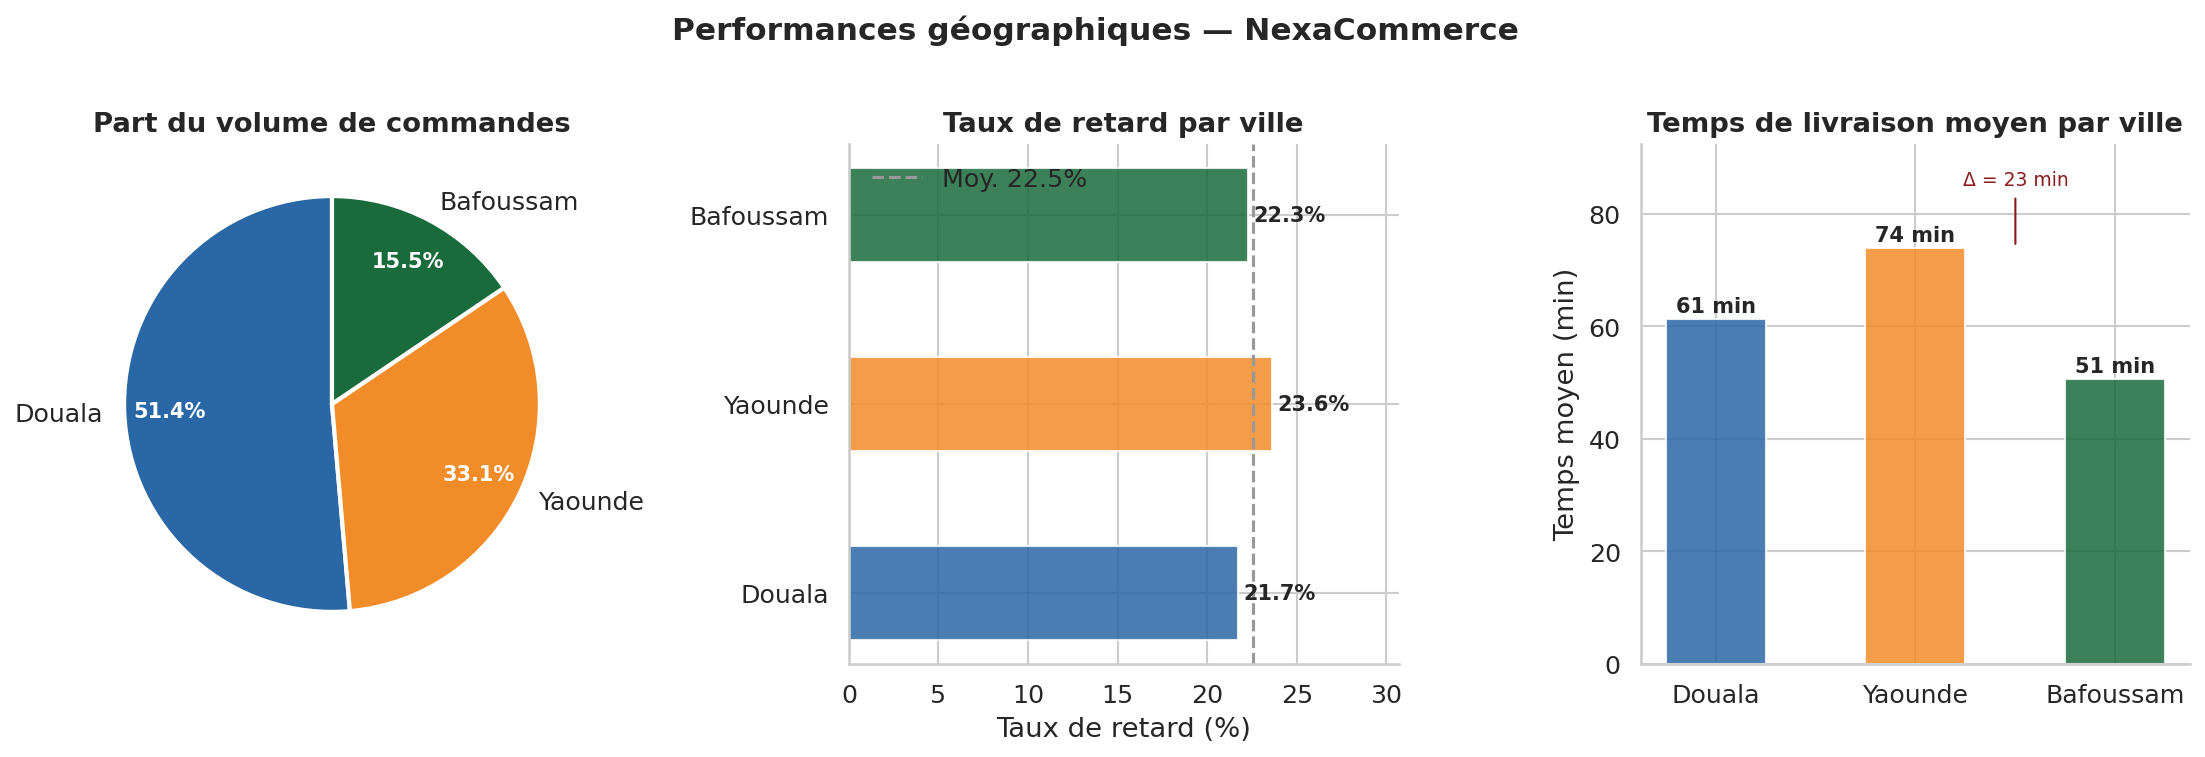

In [ ]:
cities = ["Douala", "Yaounde", "Bafoussam"]

city_colors = [COLORS[c] for c in cities]

city_stats = (
    orders
    .groupby("city")
    .agg(
        orders       = ("order_id",          "count"),
        revenue      = ("total_amount_xaf",  "sum"),
        avg_basket   = ("total_amount_xaf",  "mean"),
        late_rate    = ("status",      lambda x: (x == "late").mean() * 100),
        avg_delivery = ("delivery_time_min", "mean"),
    )
    .loc[cities]
    .round(1)
)

analysis = orders.merge(
    customers[['customer_id','name','city','loyalty_score','profile']],
    on='customer_id',
    how='left',
    suffixes=('_order','_cust')    
)

agg = analysis.groupby('city_order')['status'].sum().reset_index()
agg['total'] = agg['stauts'].sum(axis=1)

display(city_stats)

fig, axes = plt.subplots(2, 3, figsize=(15, 5))

ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    city_stats["orders"],
    labels=cities,
    colors=city_colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
ax1.set_title("Part du volume de commandes", fontweight="bold")


ax2 = axes[1]
bars = ax2.barh(cities, city_stats["late_rate"], color=city_colors,
                height=0.5, alpha=0.85)
for bar, val in zip(bars, city_stats["late_rate"]):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax2.axvline(city_stats["late_rate"].mean(), color=COLORS["neutral"],
            lw=1.5, ls="--", label=f"Moy. {city_stats['late_rate'].mean():.1f}%")
ax2.set_xlabel("Taux de retard (%)")
ax2.set_title("Taux de retard par ville", fontweight="bold")
ax2.set_xlim(0, city_stats["late_rate"].max() * 1.3)
ax2.legend()


ax3 = axes[2]
bars3 = ax3.bar(cities, city_stats["avg_delivery"], color=city_colors,
                width=0.5, alpha=0.85)
for bar, val in zip(bars3, city_stats["avg_delivery"]):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.0f} min", ha="center", va="bottom",
             fontsize=10, fontweight="bold")
ax3.set_ylabel("Temps moyen (min)")
ax3.set_title("Temps de livraison moyen par ville", fontweight="bold")
ax3.set_ylim(0, city_stats["avg_delivery"].max() * 1.25)


diff = city_stats.loc["Yaounde", "avg_delivery"] - city_stats.loc["Bafoussam", "avg_delivery"]
ax3.annotate(f"Δ = {diff:.0f} min",
             xy=(1.5, city_stats.loc["Yaounde", "avg_delivery"]),
             xytext=(1.5, city_stats["avg_delivery"].max() * 1.15),
             ha="center", fontsize=9, color=COLORS["danger"],
             arrowprops=dict(arrowstyle="-", color=COLORS["danger"]))


ax4 = axes[3]
bars4 = ax4.bar(analysis, analysis[''])

fig.suptitle("Performances géographiques — NexaCommerce", fontsize=15,
              fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig( "../reports/EDA/geo_performances.png", bbox_inches="tight", dpi=150)
plt.show()

### Interpretation
Ce graphique ci dessus nousregourpe les performances géographique de nexacommerce, incluant, les part de volume de commandes, les taux de retard par ville, et les temps moyen de livraison par ville. D'apres le graphique nous remarquons que Douala est notre ville phare, suivi de yaoundé grace au taux de commande mais une mauvaise logistique. 

### Chiffre d'affaire par catégorie de produit

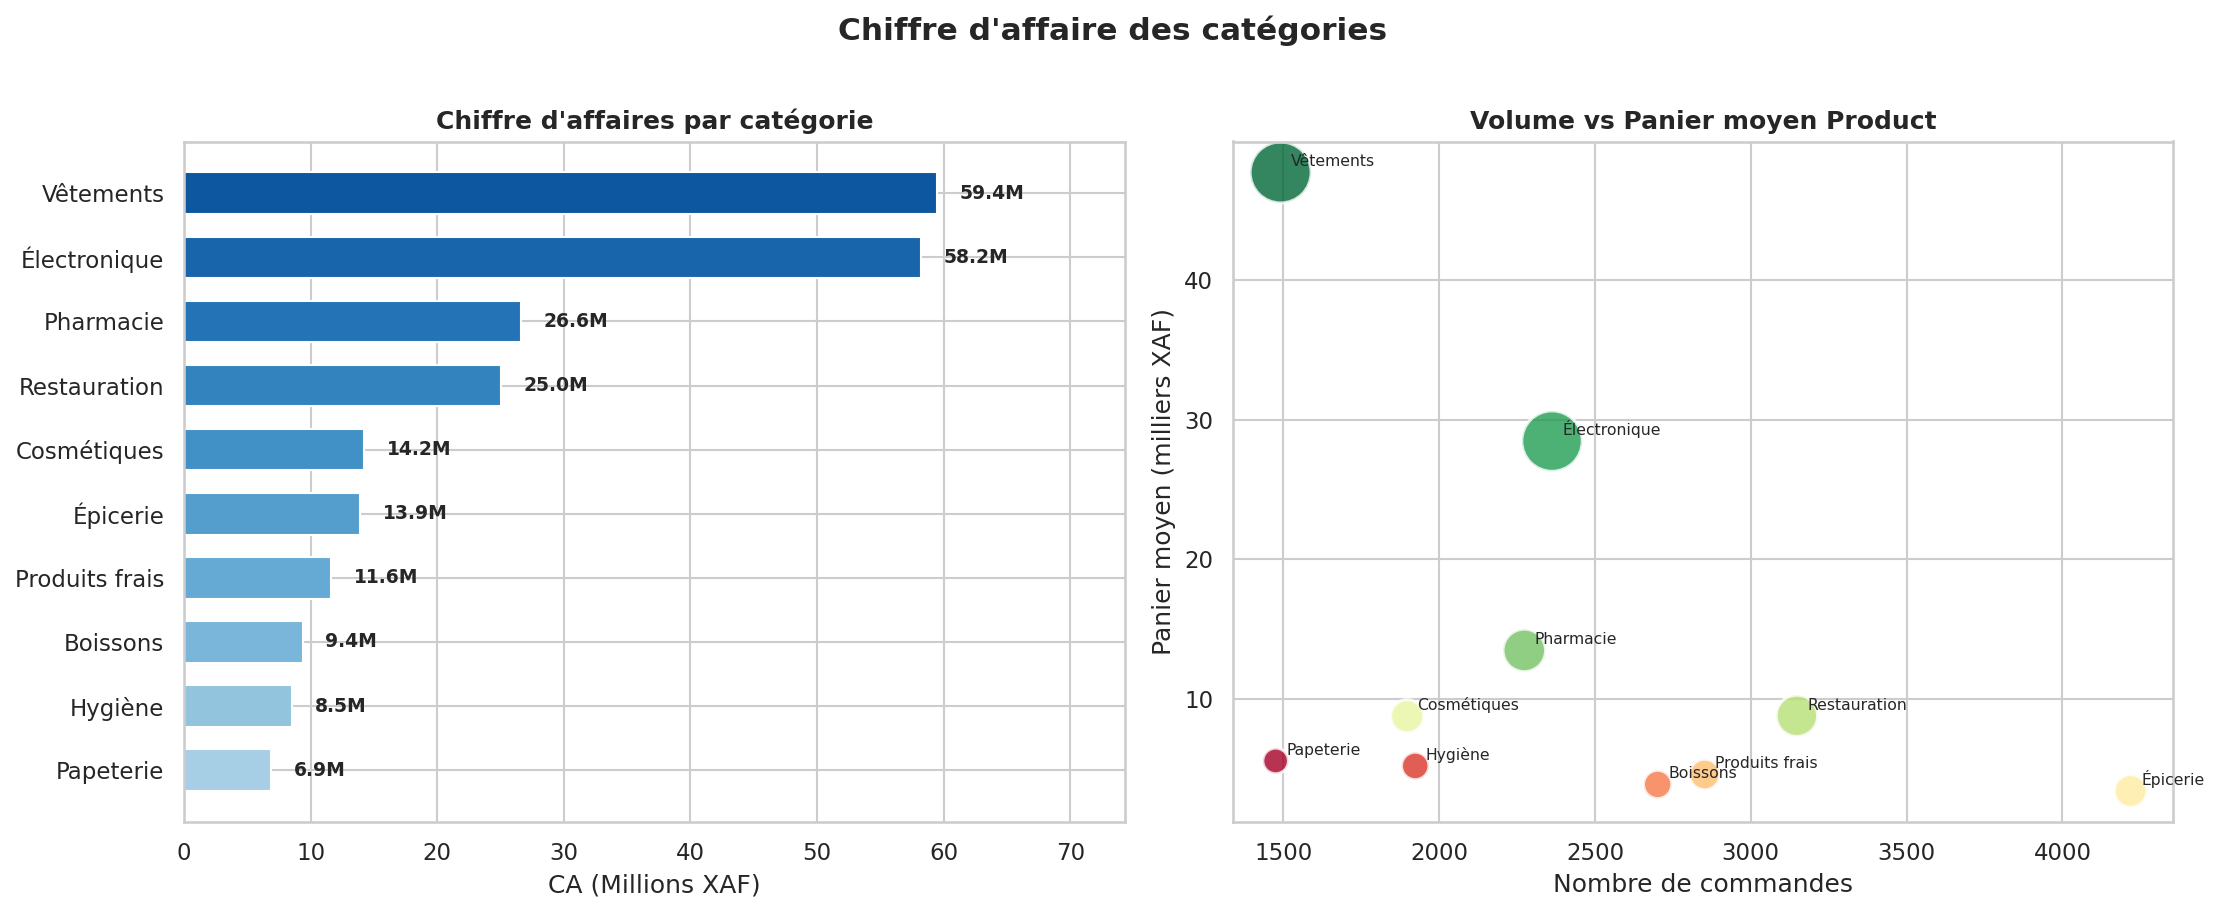

In [139]:
# Prépare la données
df_merged= order_items.merge(
    orders[['order_id','status']],
    on='order_id',
    how='inner'    
) 

df_valid = df_merged[df_merged['status'].isin(['delivered','late'])].copy()

cat_stats = (
    df_valid
    .dropna(subset=["product_category"])
    .groupby("product_category", as_index=True)
    .agg(
        orders=("order_id", "nunique"),            
        revenue=("line_total_xaf", "sum"),        
        avg_basket=("line_total_xaf", "mean"),    
    )
    .sort_values("revenue", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


ax = axes[0]
colors_cat = plt.cm.Blues(np.linspace(0.35, 0.85, len(cat_stats)))
bars = ax.barh(cat_stats.index, cat_stats["revenue"] / 1e6,
               color=colors_cat, height=0.65, edgecolor="white")
for bar, val in zip(bars, cat_stats["revenue"] / 1e6):
    ax.text(val + 0.03 * cat_stats["revenue"].max() / 1e6,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}M", va="center", fontsize=9, fontweight="bold")
ax.set_xlabel("CA (Millions XAF)")
ax.set_title("Chiffre d'affaires par catégorie", fontweight="bold")
ax.set_xlim(0, cat_stats["revenue"].max() / 1e6 * 1.25)



ax2 = axes[1]
sizes = cat_stats["revenue"] / cat_stats["revenue"].max() * 800 + 60
sc = ax2.scatter(
    cat_stats["orders"],
    cat_stats["avg_basket"] / 800,
    s=sizes,
    c=np.arange(len(cat_stats)),
    cmap="RdYlGn",
    alpha=0.8,
    edgecolors="white",
    linewidth=1.5,
)


for cat, row in cat_stats.iterrows():
    ax2.annotate(
        cat,
        (row["orders"], row["avg_basket"] / 800),
        fontsize=7.5,
        xytext=(5, 3),
        textcoords="offset points",
    )
ax2.set_xlabel("Nombre de commandes")
ax2.set_ylabel("Panier moyen (milliers XAF)")
ax2.set_title("Volume vs Panier moyen Product", fontweight="bold")

fig.suptitle("Chiffre d'affaire des catégories", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig("../reports/EDA/CA_categories_produits.png", bbox_inches="tight", dpi=150)
plt.show()

#### Interprétation
Le graphique ci dessus nous montre les produits phares, les produits les plus convoités qui ont été livré et en retards, ainsi que le volume de commandes qu'ils representent.

In [ ]:
# Preparer la données
df_merge = orders.merge(couriers, left_on='courier_id', right_on='courier_id', how='inner')
df_performance = df_merge[df_merge['status'].isin(['delivered', 'late'])].copy()

courier_stats = df_performance.groupby(['courier_id', 'name', 'city_y', 'vehicle_type', 'rating', 'is_active']).agg(
    nb_livraisons=('order_id', 'count'),
    taux_retard=('status', lambda x: (x == 'late').mean() * 100),
    temps_moyen=('delivery_time_min', 'mean')
).reset_index()

active_couriers = courier_stats[courier_stats['is_active'] == 1].copy()

top_15 = active_couriers.nlargest(15, 'nb_livraisons')

fig1 = px.bar(
    top_15, 
    x='name', 
    y='nb_livraisons', 
    color='city_y',
    title="<b>Top 15 des Livreurs Actifs par Volume de Livraisons</b>",
    labels={'name': 'Nom du Livreur', 'nb_livraisons': 'Nombre de Livraisons', 'city_y': 'Ville'},
    text_auto=True
)
fig1.update_layout(xaxis_tickangle=-45, plot_bgcolor='white')
fig1.show()

fig1.write_html('../reports/EDA/Livreurs_Actifs.html')


city_distribution = active_couriers.groupby('city_y')['courier_id'].nunique().reset_index()
city_distribution.columns = ['Ville', 'Nb_Livreurs_Actifs']

fig2 = px.bar(
    city_distribution, 
    x='Ville', 
    y='Nb_Livreurs_Actifs',
    color='Ville',
    title="<b>Répartition des Effectifs Livreurs Actifs par Ville</b>",
    text_auto=True
)
fig2.update_layout(plot_bgcolor='white', yaxis_title="Nombre de livreurs uniques")
fig2.show()
fig2.write_html('../reports/EDA/Repartition_livreurs.html')


active_couriers['est_anomalie'] = (
    (active_couriers['rating'] >= 4.0) & 
    (active_couriers['taux_retard'] > 25) & 
    (active_couriers['nb_livraisons'] >= 5)
)

fig3 = px.scatter(
    active_couriers,
    x="rating",
    y="taux_retard",
    size="nb_livraisons",       
    color="est_anomalie",        
    symbol="city_y",             
    hover_name="name",
    hover_data={
        "vehicle_type": True, 
        "nb_livraisons": True, 
        "temps_moyen": ":.0f",
        "est_anomalie": False     
    },
    color_discrete_map={False: "#3498DB", True: "#E74C3C"}, # Bleu et Rouge
    size_max=50,
    title="<b>Matrice Qualité : Rating Client vs Taux de Retard</b><br><sup>Taille = Volume | Couleur Rouge = Anomalie (Bon rating mais beaucoup de retards)</sup>",
    labels={"rating": "Score / Rating Client", "taux_retard": "Taux de Retard (%)", "city_y": "Ville"}
)

# Ajout des lignes de seuils pour délimiter les zones
fig3.add_hline(y=25, line_dash="dash", line_color="red", 
               annotation_text="Seuil Alerte Retard (25%)", annotation_position="top left")
fig3.add_vline(x=4.0, line_dash="dash", line_color="orange", 
               annotation_text="Median", annotation_position="bottom left")

fig3.update_layout(plot_bgcolor='white')
fig3.show()
fig3.write_html('../reports/EDA/Audit_livreur.html')




### Interpretation
Cette figure nous montre les chiffres d'affaire generer par les produits.  

#### Interpretation 
Le graphique nous présente les livreurs les plus perfomants.


### Temps moyen de livraison par jour


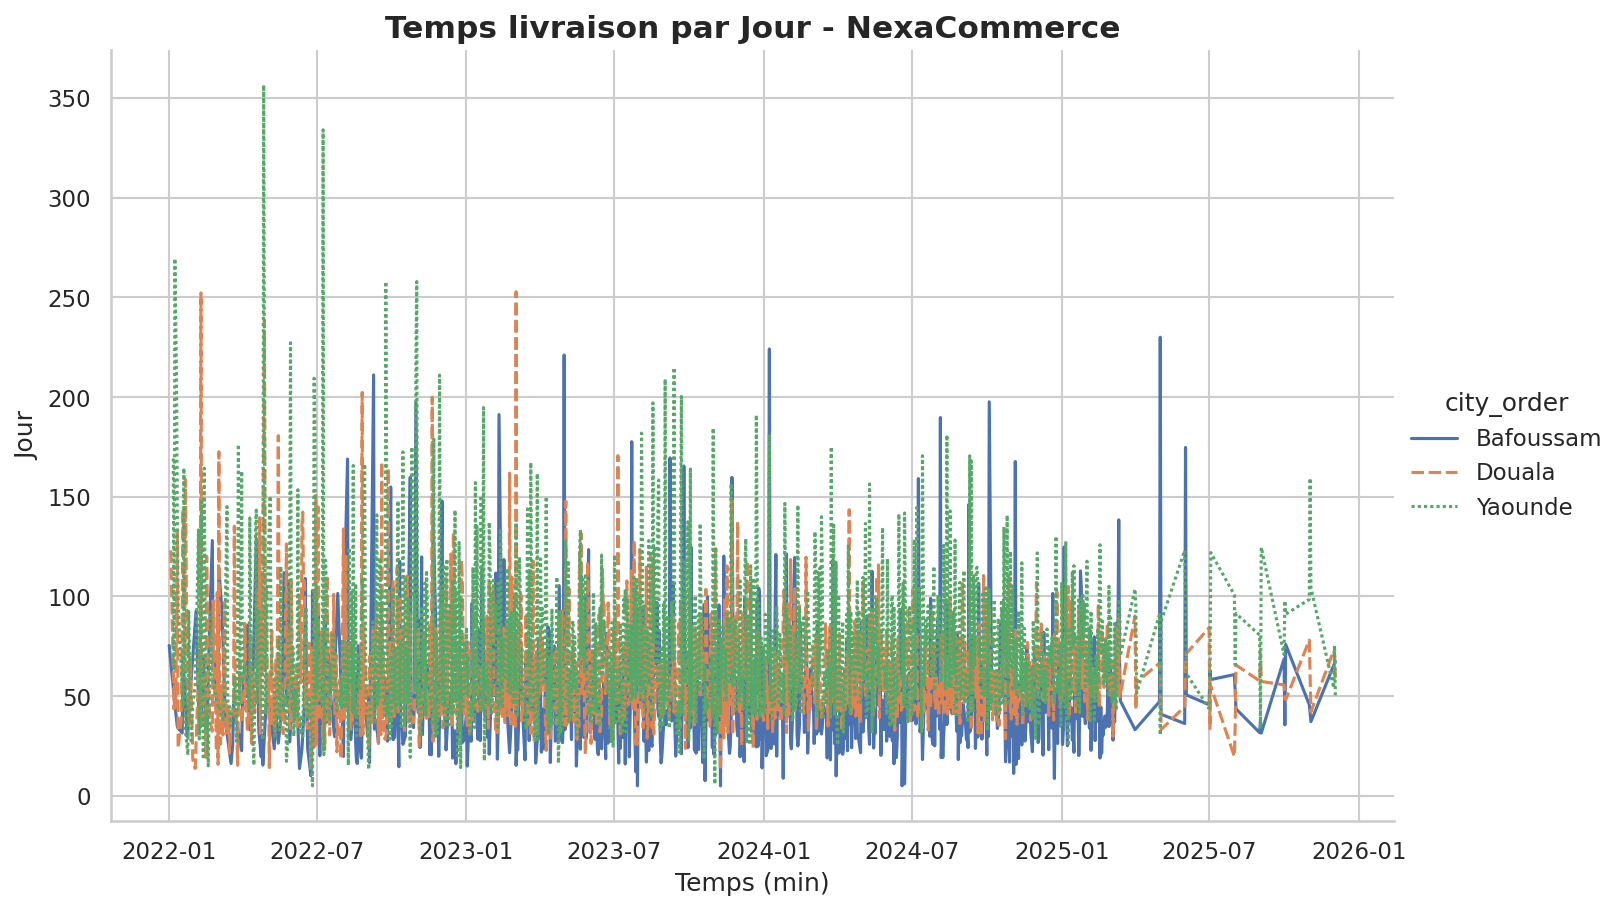

In [93]:
analysis = orders.merge(
    customers[['customer_id','name','city','loyalty_score','profile']],
    on='customer_id',
    how='left',
    suffixes=('_order','_cust')    
)

daily = analysis.groupby([analysis['order_date'].dt.date, 'city_order'])['delivery_time_min'].mean().reset_index()
daily_wide = daily.pivot(index='order_date', columns='city_order', values='delivery_time_min')
sns.relplot(data=daily_wide, kind='line', height=6, aspect=1.6)


plt.title("Temps livraison par Jour - NexaCommerce", fontsize=15, fontweight='bold')
plt.xlabel("Temps (min)")
plt.ylabel("Jour")
fig.savefig("../reports/EDA/Time_day.png", bbox_inches="tight", dpi=150)
plt.show()

#### Interprétation
Le graphique suivant nous montre les moyennes journaliers des temps de livraison en fonction des villes. Nous constatons que la ville de yaoundé à une moyenne de temps de livraison largement supérieur au autre ville. Ceux ci peut etre du au faite que la logistique sur la ville de yaoundé pourrais etre ne pas bonne. 

### Créneau honoraire de la journée

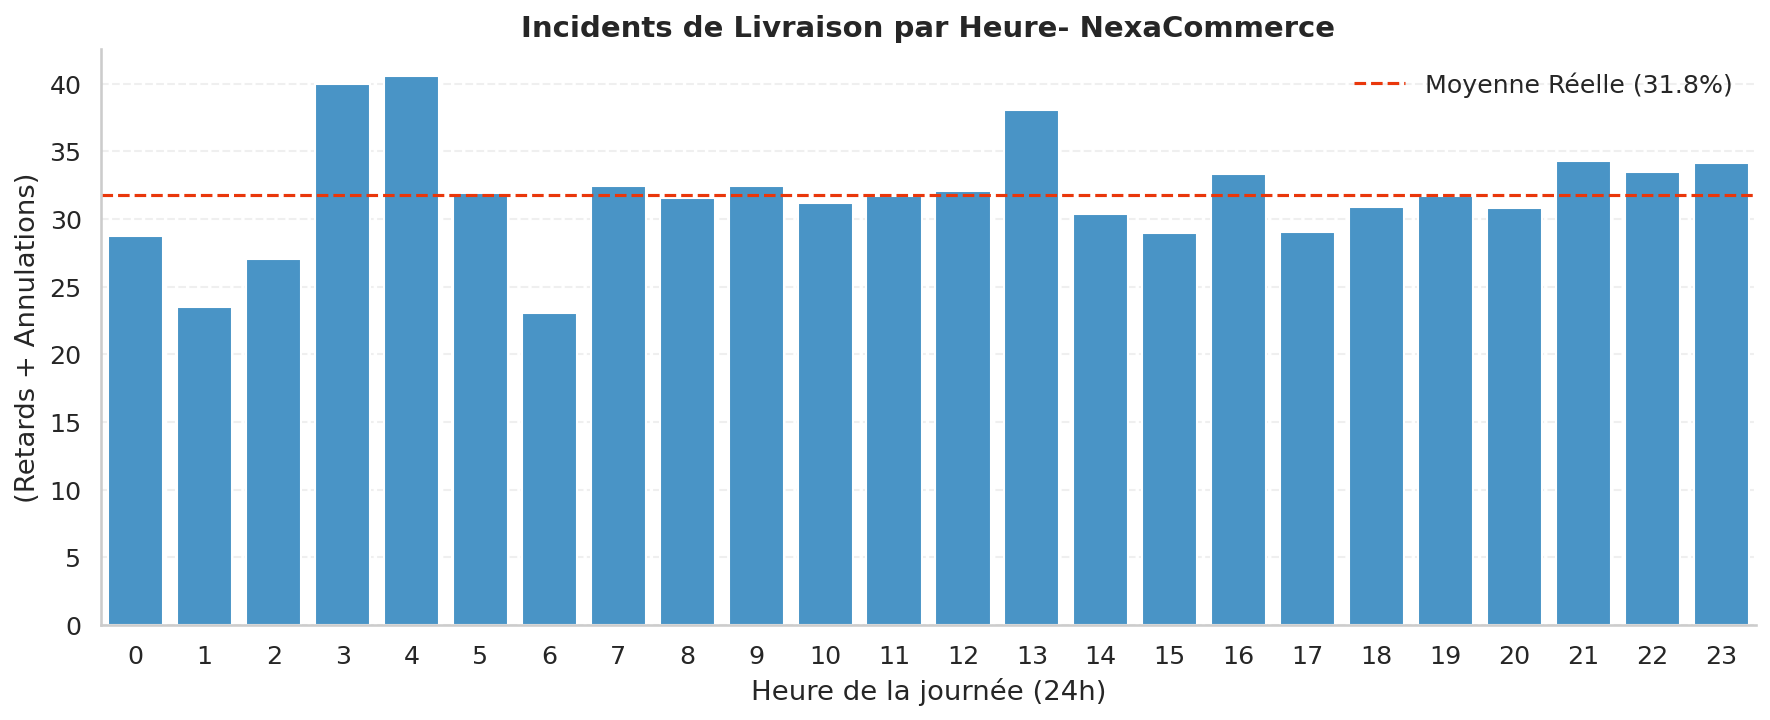

In [ ]:
orders['is_problematic'] = orders['status'].isin(['late', 'cancelled'])



hourly_stats = orders.groupby('order_hour')['is_problematic'].agg(['count', 'mean']).reset_index()
hourly_stats.columns = ['heure', 'total_commandes', 'taux_retard']
hourly_stats['taux_retard_pct'] = hourly_stats['taux_retard'] * 100

# Moyenne
moyenne_globale_reelle = (orders['is_problematic'].sum() / len(orders)) * 100

plt.figure(figsize=(12, 5))


sns.barplot(data=hourly_stats, x='heure', y='taux_retard_pct', color='#3498db')

# Ligne moyenne
plt.axhline(y=moyenne_globale_reelle, color="#e9370b", linestyle='--', 
            label=f'Moyenne Réelle ({moyenne_globale_reelle:.1f}%)')

# Heure faible volume
for i, row in hourly_stats.iterrows():
    if row['total_commandes'] < 5: 
        plt.text(i, row['taux_retard_pct'] + 0.5, '!', color='red', ha='center', fontweight='bold')

plt.title("Incidents de Livraison par Heure- NexaCommerce", fontsize=14)
plt.xlabel("Heure de la journée (24h)")
plt.ylabel("(Retards + Annulations)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
fig.savefig("../reports/EDA/histograme_heure.png", bbox_inches="tight", dpi=150)
plt.show()

### Interpretation 
Le graphique ci-dessus présente le taux d'incident total au cours des heures dans NexaCommerce. Nous remarquons que nous avons des incidence plus élévé autoir de 4h, et 4h du matin, des commandes qui ont un fort taux de retards et d'annulation. 

### Heure Jour qui ont le plus de retards

Une heatmap révèle immédiatement les zones de tension opérationnelle. Taux de retard parmis les livraisons.  

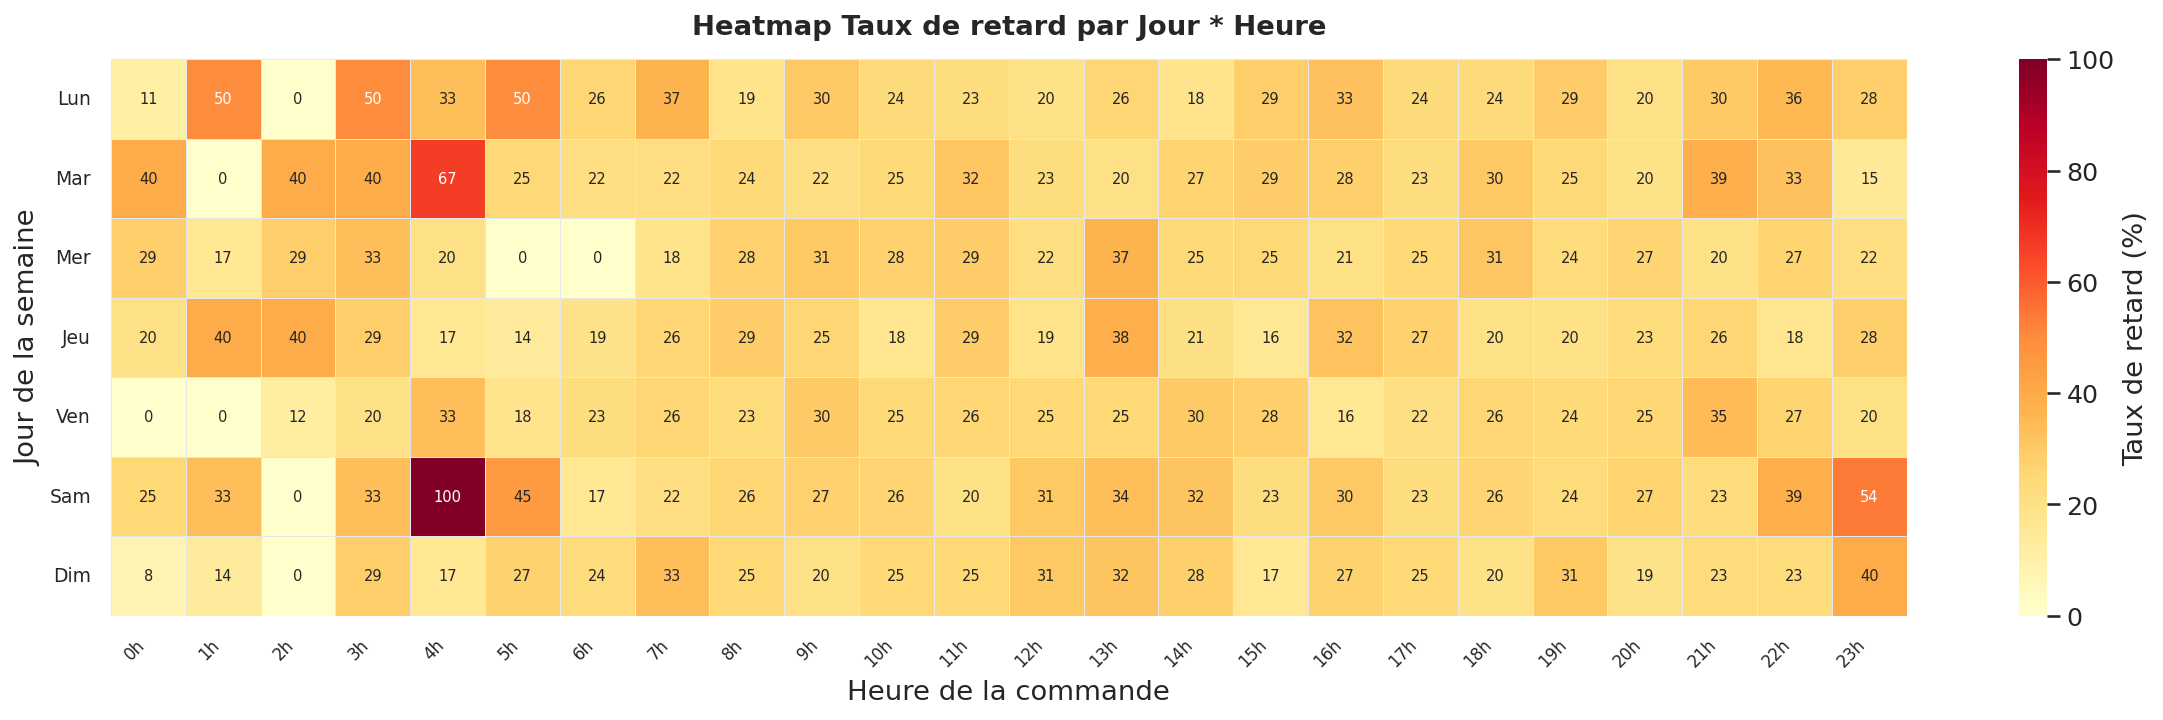

In [71]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
              "Friday",  "Saturday", "Sunday"]
dow_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

status_reussis = ['delivered', 'late']
orders_valid = orders[orders['status'].isin(status_reussis)].copy()

heatmap_data = (
    orders_valid
    .groupby(["order_day_of_week", "order_hour"])["status"]
    .apply(lambda x: (x == "late").mean() * 100)
    .reset_index()
)

heatmap_data.columns = ["Jour", "Heure", "Taux_Retard"]

pivot = (
    heatmap_data
    .pivot(index="Jour", columns="Heure", values="Taux_Retard")
    .reindex(dow_order)    
)


fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.3,
    linecolor="#E5E7EB",
    cbar_kws={"label": "Taux de retard (%)"},
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_yticklabels(
    [dow_labels[dow_order.index(d)] for d in pivot.index],
    rotation=0, fontsize=9
)
ax.set_xticklabels(
    [f"{h}h" for h in pivot.columns],
    rotation=45, ha="right", fontsize=8
)
ax.set_xlabel("Heure de la commande")
ax.set_ylabel("Jour de la semaine")
ax.set_title(
   "Heatmap Taux de retard par Jour * Heure",
    fontweight="bold", pad=12
)

plt.tight_layout()
fig.savefig("../reports/EDA/Heatmap_Jour_X_Heure.png")
plt.show()

Nous remarquons que la journée de la semaine samedi à 4h à un taux de retard à 100 %, ainsi que les journée de Mardi à 4h et samedi à 22h qui ont les plus gros taux de retard

### Score des liveurs par ville

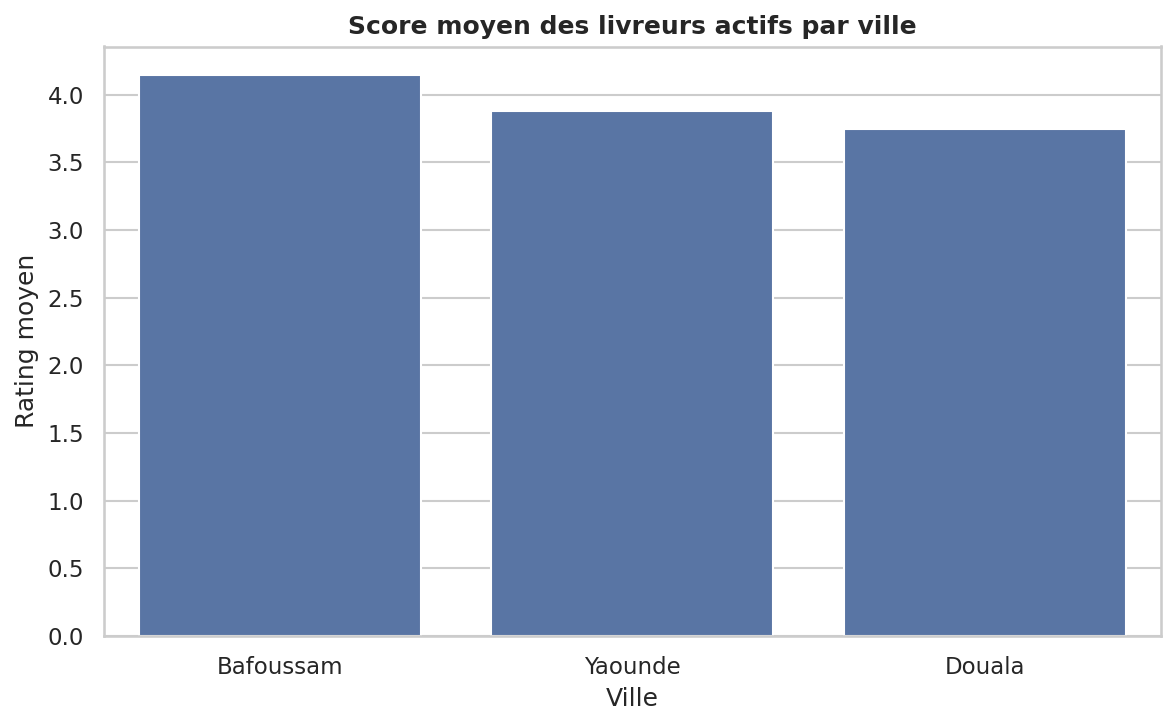

In [148]:
active_couriers = couriers[couriers["is_active"] == True].copy()
active_couriers.head()

active_couriers['city'] = active_couriers['city'].map(city_normalise)

active_courier_scores_by_city = (
    active_couriers.groupby("city")["rating"]
    .mean()
    .reset_index()
    .sort_values("rating", ascending=False)
)

active_courier_scores_by_city

plt.figure(figsize=(8, 5))
sns.barplot(
    data=active_courier_scores_by_city,
    x="city",
    y="rating"
)
plt.title("Score moyen des livreurs actifs par ville")
plt.xlabel("Ville")
plt.savefig("../reports/EDA/Score_livreur_ville.png", bbox_inches="tight", dpi=150)

plt.ylabel("Rating moyen")
plt.show()

#### Interprétation
Le graphique nous montre les villes dont les livreus actifs ont été les plus notés.  

  city_order  is_delivered  is_late  is_cancelled  is_in_progress  total
0  Bafoussam          1258      433           184              68   1943
1     Douala          4195     1395           606             226   6422
2    Yaounde          2650      974           380             131   4135


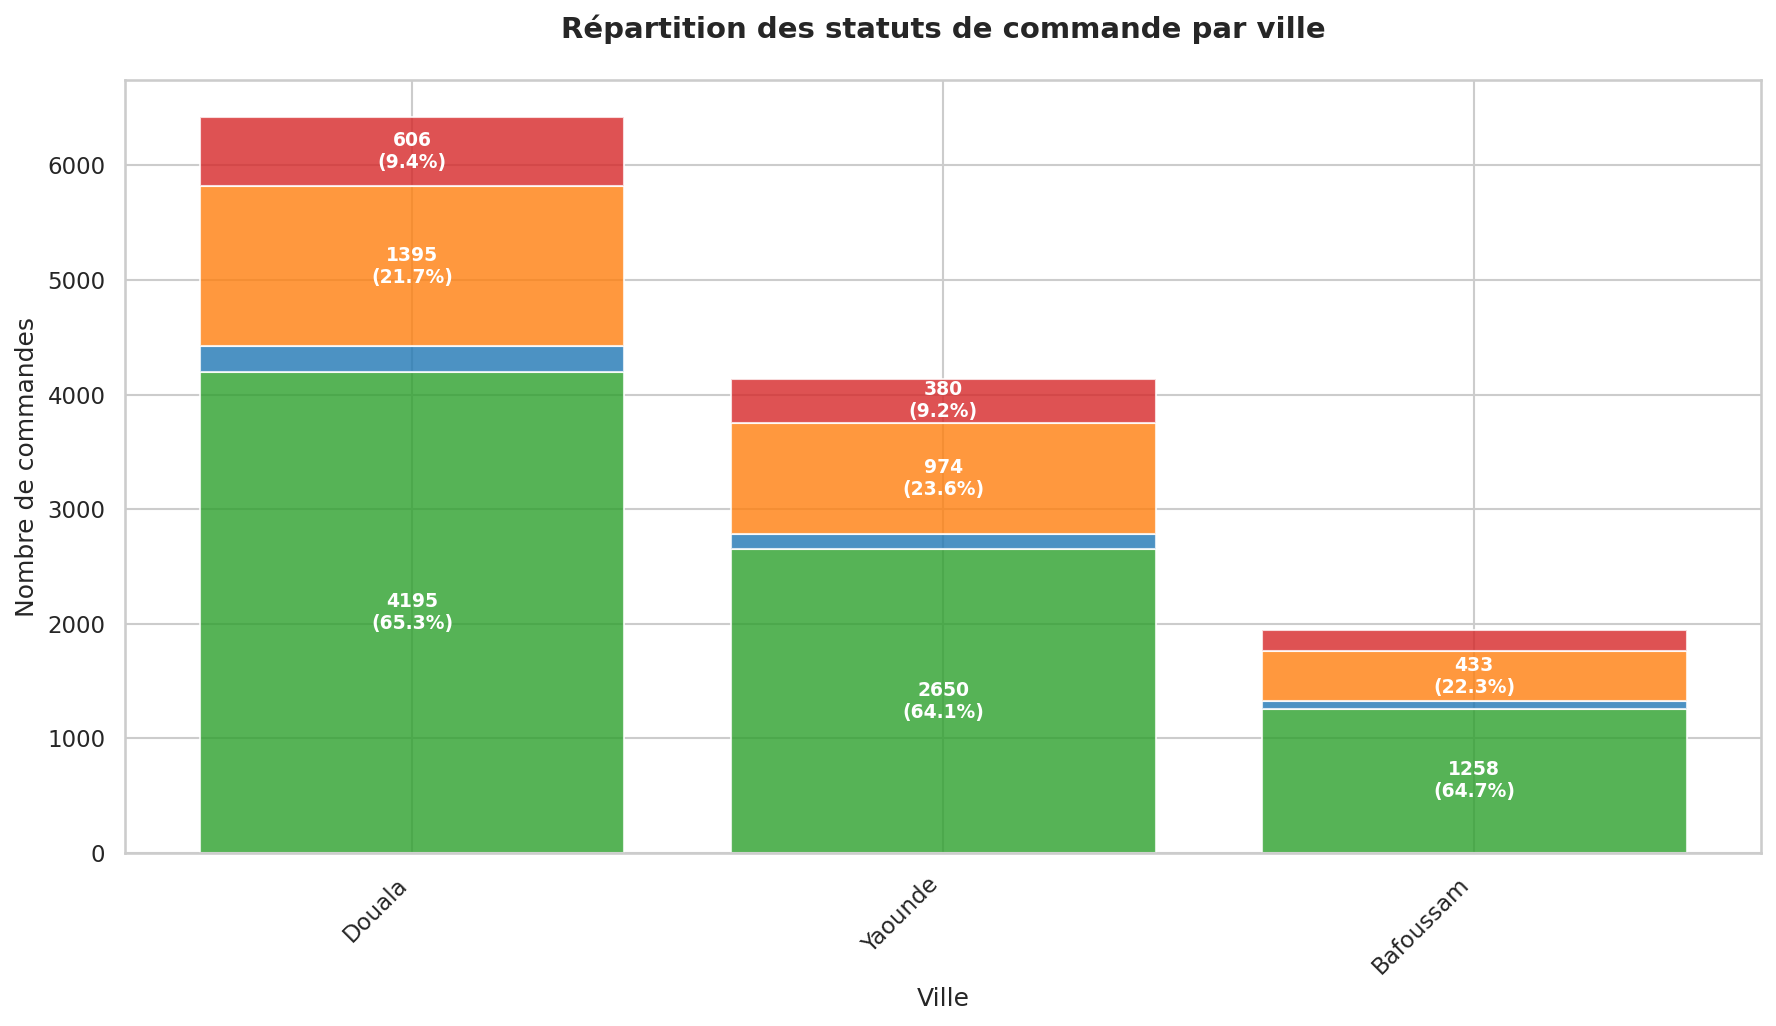

In [149]:

for status in ['delivered', 'late', 'cancelled', 'in_progress']:
    col_name = f"is_{status.replace(' ', '_')}"
    analysis[col_name] = (analysis['status'] == status).astype(int)

cols_to_sum = ['is_delivered', 'is_late', 'is_cancelled', 'is_in_progress']
agg = analysis.groupby('city_order')[cols_to_sum].sum().reset_index()
agg['total'] = agg[cols_to_sum].sum(axis=1)

print(agg)

for col in cols_to_sum:
    agg[col + '_pct'] = (agg[col] / agg['total']) * 100

agg = agg.sort_values('total', ascending=False).reset_index(drop=True)

# 5. Visualisation
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

plot_configs = [
    {'col': 'is_delivered', 'label': 'Livré', 'color': '#2ca02c'},
    {'col': 'is_in_progress', 'label': 'En cours', 'color': '#1f77b4'},
    {'col': 'is_late', 'label': 'En retard', 'color': '#ff7f0e'},
    {'col': 'is_cancelled', 'label': 'Annulé', 'color': '#d62728'}
]

bottom = pd.Series([0.0] * len(agg))

for config in plot_configs:
    plt.bar(agg['city_order'], agg[config['col']], bottom=bottom, 
            label=config['label'], color=config['color'], alpha=0.8)
    
    # Ajout des annotations au milieu de chaque segment
    for idx, row in agg.iterrows():
        val = row[config['col']]
        pct = row[config['col'] + '_pct']
        if val > (agg['total'].max() * 0.05):  # On n'affiche que si le segment est assez large
            plt.text(idx, bottom[idx] + val/2, f"{int(val)}\n({pct:.1f}%)", 
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    
    bottom += agg[config['col']]

plt.xticks(rotation=45, ha='right')
plt.xlabel("Ville")
plt.ylabel("Nombre de commandes")
plt.title("Répartition des statuts de commande par ville", fontsize=14, pad=20)
plt.savefig('../reports/EDA/Status_par_ville.png')
plt.tight_layout()
plt.show()


#### Interprétation
Le graphique met en évidence les commandes, taux de commandes, pourcentage de commande dans une ville. c'est à dire si Douala traite le plus gros volume, le taux de commandes 'en_retard' y est proportionnellement plus élevé qu'à Yaoundé. Ceci nous apprends que le retard sur les commandes ne sont dû au faite qu'il puisse avoir beauoup de commande dans la ville, mais plûtot au niveau de la densité de la population.

#### interpretaion
Avec ce graphique nous pouvons voir que nous avons 9.4 % des commandes qui sont annulées.   

## Insight pour la direction

Ici nous identifions les idées pour aider à améliorer le service marketing et financier de nexacommerce.

1. *L'activité à certains heure de la journée.*

Est ce que le volume de commandes est complètement homogène sur le temps de la journée, mais aussi est ce que le faite de se faire livrér a certains heure de la journée pourrais avoir un impact sur le retard d'une commande. 
    Il faudrais adpater la logistique en fonction

2. *Activité sur les categories des produits*

Quelle sont les produits qui sont les plus annulés ? ex: La categorie Épicerie represente quel pourcentage dans le taux d'annulation des commandes ? L'annulation d'une commande depends t-il de son produit ? Il faudrais pouvoir elargir le réseaux pour reduire le temps d'attente pour un produit qu'on peut possiblement trouvé à côté.

3. *Fidélisation et clientelle*

Est ce que les clients les plus fidèle sont plus servis que les autres ? Est ce que les clients premium avec un fort panier moyen ont un privilège par rapport au autre client ? Est ce qu'il exite une corrélation entre le loyalty_score d'un client et son pannier moyen ? Il faudrais que les clients les plus fidèles soit les plus satisfait pour augmenter le panier moyen de celui ci et recevoir d'autre client. 

4. *Annulation de commandes*

Est ce que les annulations de commandes sont dûe au faites de ne pas avoir de la monaie ? Alors pour cela il faudrais encourager les méthodes de paiement mobiles pour éviter les annulations. 

5. *Performance des liveurs*

Les livreurs les plus performant recoivent t-il un meilleur salaire ? Avons nous beaucoup de temps de livraison qui sont en dehors des outliers ont un impacte sur la finance ?  Pour les livreurs les plus prompts il faudrais pouvoir leur fournir une récompenses.

## Exécutive Summary

Cette analyse vise à évaluer la performance opérationnelle et commerciale de NexaCommerce à partir des données de commandes, clients et livreurs, afin d’identifier les leviers d’optimisation logistique et de croissance de l'entreprise.
L'analyse de plus de 5 ans de données opérationnelles confirme une trajectoire de croissance solide pour NexaCommerce puis une chute brutale vers février 2025. 
Cependant, l'histoire des données révèle des frictions logistiques critiques à Yaoundé et lors des pics d'activité qui freinent la rentabilité et la fidélisation client du côté de yaoundé. Mais par ailleur nous avons aussi nombre de retard dans la ville de douala  qui est plus ou moins pareille que le pourcentage de retard dans la ville de Yaoundé ce qui prouve que le retard des commandes ne dépends pas de la quantité de commande mais de la logistique.
La donnée nous raconte alors : 
- Résoudre les problèmes de logistique dans la ville de yaoundé.

- Douala est le principal levier de croissance avec un fort impact.   

- La qualité de données (ex: numero télephone table customers, ainsi que les montants) est un problème dans les analyses.

- Les  retards repete est un soucis pour l'expérience client. 

Les recomandations proposez par rapport à ça serais : 

-  Prioriser la logistique à yaoundé.

-  Prioriser la logistique à certaines heure de la journée 

-  Mettre en place un suivi des client premium 

In [ ]:
del orders['is_problematic']
del orders['month']
del orders['ecart_montant']
del orders['total_amount_xaf'] 
display(orders)

,order_id,customer_id,order_date,delivery_time_min,status,total_amount_xaf,city,quartier,courier_id,order_hour,order_day_of_week,total_amount_xaf_clean,ecart_montant,is_problematic,month
0,100000,CUST11954,2024-07-06 14:31:00,44.7,delivered,15444.0,Yaounde,Biyem-Assi,47,14,Friday,7594.0,7850.0,False,2024-07-01
1,100001,CUST11317,2024-04-20 18:56:00,53.9,delivered,16188.0,Yaounde,Messa,32,18,Saturday,227.0,15961.0,False,2024-04-01
2,100002,CUST17374,2024-10-07 17:37:00,260.7,late,11497.0,Douala,Bonabéri,32,17,Wednesday,10159.0,1338.0,True,2024-10-01
3,100003,CUST10224,2023-03-29 07:48:00,253.8,late,20301.0,Yaounde,Nlongkak,22,7,Wednesday,17776.0,2525.0,True,2023-03-01
4,100004,CUST11846,2024-12-29 08:35:00,66.5,delivered,15639.0,Yaounde,Bastos,30,8,Sunday,1318.0,14321.0,False,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12495,112495,CUST11295,2024-05-22 19:42:00,202.8,late,39113.0,Bafoussam,Mossap,28,19,Wednesday,5292.0,33821.0,True,2024-05-01
12496,112496,CUST11910,2023-07-02 18:26:00,41.4,delivered,4776.0,Bafoussam,Lekie,21,18,Tuesday,2298.0,2478.0,False,2023-07-01
12497,112497,CUST11847,2023-05-06 00:00:00,50.3,delivered,50750.0,Douala,Bonabéri,35,9,Saturday,26402.0,24348.0,False,2023-05-01
12498,112498,CUST10517,2023-10-05 13:19:00,10.1,cancelled,18000.0,Douala,Makepe,33,13,Thursday,1820.0,16180.0,True,2023-10-01


In [ ]:
display(customers)
del['profile']

,customer_id,name,phone,registration_date,city,quartier,loyalty_score,profile
0,CUST11544,Luc ALI,646521025,2021-03-01,Douala,Akwa,19.800000,Inactif / Occasionnel
1,CUST10713,MENDO Chancelle,639254705,2021-03-01,Yaounde,Mvog-Mbi,61.400000,Actif
2,CUST10198,OUMAR NDONGO,651837852,2021-03-01,Bafoussam,Centre Ville,43.464154,Actif
3,CUST10439,Jean BILONG,613326769,2021-03-02,Yaounde,Biyem-Assi,17.400000,Inactif / Occasionnel
4,CUST12034,Armelle LOBE,659167775,2021-03-02,Bafoussam,Djeleng,25.700000,Actif
...,...,...,...,...,...,...,...,...
1913,CUST12010,DIDIER MBASSI,657183837,2024-12-30,Yaounde,Briqueterie,53.400000,Actif
1914,CUST10403,EKOTTO Boris,645159040,2024-12-31,Yaounde,Biyem-Assi,69.900000,Actif
1915,CUST11561,THIERRY WAMBA,675314742,2024-12-31,Douala,Bonamoussadi,48.100000,Actif
1916,CUST11761,DOUMBIA Marie,680651318,2025-01-01,Bafoussam,Kamkop,60.800000,Actif


In [157]:
couriers['phone'] = couriers['phone'].map(normalise_phone)
display(couriers)

,courier_id,name,phone,city,vehicle_type,join_date,is_active,rating
0,1,Mireille BARKA,NaN,Bafoussam,Voiture,2023-07-12,1,3.6
1,2,Gisèle MAROUF,687125015,Douala,Moto,2022-02-21,1,3.4
2,3,Constant NGUEFACK,NaN,Douala,Moto,2023-05-22,0,3.1
3,4,Josephine DJOUMESSI,660932893,Douala,Vélo,2022-05-31,1,2.6
4,5,Guy ESSOH,669441885,Yaoundé,Tricycle,2023-02-16,1,4.7
5,6,Isabelle ABATE,643469574,Bafoussam,Moto,2023-08-15,1,4.0
6,7,Lydie ISSA,624394282,Douala,Tricycle,2022-08-24,0,2.5
7,8,Rémi MBOCK,NaN,Douala,Voiture,2022-07-05,1,4.8
8,9,Sophie KAMGA,698664032,Douala,Moto,2023-07-29,1,2.9
9,10,Oumar OBAMA,693690185,Yaoundé,Vélo,2023-03-27,1,4.4


In [158]:

orders.to_csv('../data/reports/orders_clean.csv', index=False, encoding='utf-8-sig')
customers.to_csv('../data/reports/customers_clean.csv', index=False, encoding='utf-8-sig')
order_items.to_csv('../data/reports/order_items.csv', index=False, encoding='utf-8-sig')
couriers.to_csv('../data/reports/couriers.csv', index=False, encoding='utf-8-sig')


print(f"Les fichiers ont été sauvegardés avec succès")

Les fichiers ont été sauvegardés avec succès
